# 1. Data Filtering

In [2]:
import pandas as pd
import numpy as np
import holidays

def clean_data_pipeline(file_path):
    # ---------------------------------------------------------
    # 0. LOAD & PREPARE
    # ---------------------------------------------------------
    print(">> Loading Data...")
    df = pd.read_csv(file_path)
    df['Time'] = pd.to_datetime(df['Time'])
    df = df.drop_duplicates(subset='Time').set_index('Time').sort_index()
    df = df.resample('h').asfreq()

    all_features = ['Elec_P_LVMDB_ETA_kW', 'humidity_percent', 'precipitation_height_mm', 
                    'temperature_air_mean_C', 'wind_speed_m_per_s']
    non_neg_features = [c for c in all_features if c != 'temperature_air_mean_C']

    # ---------------------------------------------------------
    # A. INTERNAL STATUS DETECTION (For Logic Only)
    # ---------------------------------------------------------
    print(">> Internal Status Detection...")
    
    # We create a temporary DataFrame for status logic so main df stays clean
    status_df = pd.DataFrame(index=df.index)
    
    # 1. Base Legal Holidays
    years = list(range(df.index.year.min(), df.index.year.max() + 2))
    base_holidays = holidays.DE(years=years, prov='HE')
    status_df['is_holiday'] = df.index.to_series().apply(lambda x: x.date() in base_holidays)

    # 2. Auto-Detect Hidden Holidays (Low Load Weekdays)
    daily_max = df['Elec_P_LVMDB_ETA_kW'].resample('D').max()
    threshold_closed = 12.0
    hidden_holidays = []
    
    for date, max_load in daily_max.items():
        day_str = str(date.date())
        if day_str in df.index:
            is_already = status_df.loc[day_str, 'is_holiday'].any()
            if (date.dayofweek < 5) and (not is_already) and (max_load < threshold_closed):
                if df.loc[day_str]['Elec_P_LVMDB_ETA_kW'].count() > 20:
                    hidden_holidays.append(date.date())
    
    if hidden_holidays:
        mask_hidden = df.index.to_series().apply(lambda x: x.date() in hidden_holidays)
        status_df.loc[mask_hidden, 'is_holiday'] = True

    # 3. Audit Working Holidays (High Load Holidays)
    threshold_open = 15.0
    holidays_to_remove = set()
    for date, max_load in daily_max.items():
        day_str = str(date.date())
        if day_str in df.index:
            is_holiday_flag = status_df.loc[day_str, 'is_holiday'].any()
            if is_holiday_flag and max_load > threshold_open:
                if date.date() not in hidden_holidays:
                    hol_name = base_holidays.get(date.date(), "Unknown")
                    for h_date, h_name in base_holidays.items():
                        if h_name == hol_name:
                            holidays_to_remove.add(h_date)
                            
    if holidays_to_remove:
        mask_remove = df.index.to_series().apply(lambda x: x.date() in holidays_to_remove)
        status_df.loc[mask_remove, 'is_holiday'] = False

    # 4. Working Sunday (15th Rule)
    def check_working_sunday(row):
        if row.name.day == 15 and row.name.dayofweek == 6:
            if row.name.month not in [12, 1, 2]: 
                return True
        return False
    status_df['is_working_sunday'] = df.apply(check_working_sunday, axis=1)

    # 5. Assign Status (Used for Logic)
    conditions = [
        status_df['is_working_sunday'] == True,      
        status_df['is_holiday'] == True,             
        df.index.dayofweek >= 5               
    ]
    choices = ['working', 'closed', 'closed']
    status_df['day_status'] = np.select(conditions, choices, default='working')

    # ---------------------------------------------------------
    # STEP 1: STRICT STATUS-LOCKED GAP FILLING
    # ---------------------------------------------------------
    print(">> Step 1: Gap Filling (Strict Status Matching)...")
    
    def get_strict_neighbors(target_idx, column_name):
        candidates = []
        target_status = status_df.loc[target_idx, 'day_status']
        
        # A. WEEKLY SEARCH (Deep Search 1-4 Weeks)
        # We skip weeks if status doesn't match
        weekly_lags = [168, -168, 336, -336, 504, -504, 672, -672] 
        
        for lag in weekly_lags:
            check_time = target_idx - pd.Timedelta(hours=lag)
            if check_time in df.index:
                # Check Status using our separate status_df
                if status_df.loc[check_time, 'day_status'] == target_status:
                    val = df.loc[check_time, column_name]
                    if not np.isnan(val):
                        candidates.append(val)
                        if len(candidates) >= 2: break 
        
        # B. ADJACENT SEARCH (Fallback)
        if not candidates:
            if target_status == 'working':
                # Scan adjacent days, verify they are 'working'
                daily_lags = list(range(24, 121, 24)) + list(range(-24, -121, -24))
            else:
                # Scan adjacent days, verify they are 'closed'
                daily_lags = [24, -24, 48, -48]
                
            for lag in daily_lags:
                check_time = target_idx - pd.Timedelta(hours=lag)
                if check_time in df.index:
                    if status_df.loc[check_time, 'day_status'] == target_status:
                        val = df.loc[check_time, column_name]
                        if not np.isnan(val):
                            candidates.append(val)
                            if len(candidates) >= 2: break 
                            
        return candidates

    for col in all_features:
        if df[col].isna().sum() == 0: continue
        nan_indices = df[df[col].isna()].index
        
        for idx in nan_indices:
            valid_vals = get_strict_neighbors(idx, col)
            if valid_vals:
                df.loc[idx, col] = np.mean(valid_vals)

    df = df.interpolate(method='time').bfill().ffill()

    # ---------------------------------------------------------
    # STEP 2-4: SMOOTHING & CAPPING
    # ---------------------------------------------------------
    print(">> Steps 2-4: Smoothing & Capping...")
    
    # 2. Smoothing
    for col in all_features:
        df[col] = df[col].rolling(window=3, center=True).mean().bfill().ffill()

    # 3. Winsorization
    # We use temporary columns for calculation, then drop them
    temp_df = df.copy()
    def get_season(month):
        if month in [3, 4, 5]: return 'Spring'
        elif month in [6, 7, 8]: return 'Summer'
        elif month in [9, 10, 11]: return 'Autumn'
        else: return 'Winter'
        
    temp_df['Month'] = temp_df.index.month
    temp_df['Season'] = temp_df['Month'].apply(get_season)
    temp_df['Weekday'] = temp_df.index.dayofweek
    temp_df['Hour'] = temp_df.index.hour
    
    for col in all_features:
        baseline = temp_df.groupby(['Season', 'Weekday', 'Hour'])[col].transform('mean')
        residuals = df[col] - baseline
        std_dev = residuals.std()
        
        threshold_upper = baseline + (3 * std_dev)
        df.loc[df[col] > threshold_upper, col] = threshold_upper[df[col] > threshold_upper]
        
        if col == 'temperature_air_mean_C':
            threshold_lower = baseline - (3 * std_dev)
            df.loc[df[col] < threshold_lower, col] = threshold_lower[df[col] < threshold_lower]

    # 4. Remove Negatives
    for col in non_neg_features:
        neg_mask = df[col] < 0
        if neg_mask.sum() > 0:
            valid_data = temp_df[temp_df[col] >= 0]
            seasonal_avg = valid_data.groupby(['Season', 'Weekday', 'Hour'])[col].mean().to_dict()
            temp_df['lookup_key'] = list(zip(temp_df['Season'], temp_df['Weekday'], temp_df['Hour']))
            replacement = temp_df['lookup_key'].map(seasonal_avg).fillna(0)
            df.loc[neg_mask, col] = replacement[neg_mask]

    # ---------------------------------------------------------
    # STEP 5: STRICT STATUS-LOCKED STABILIZATION
    # ---------------------------------------------------------
    print(">> Step 5: Smart Stabilization (Deep Search)...")
    
    def get_best_neighbor(direction_multiplier):
        curr_stat = status_df['day_status']
        final_lag = pd.Series(0, index=df.index)
        
        # Priority: 1 Week > 2 Weeks > 3 Weeks
        # We search deeply for a MATCHING status
        for k in [3, 2, 1]: 
            lag = 168 * k * direction_multiplier
            stat_neighbor = status_df['day_status'].shift(lag)
            
            mask = (curr_stat == stat_neighbor)
            final_lag[mask] = lag
            
        return final_lag

    past_lags = get_best_neighbor(1)
    future_lags = get_best_neighbor(-1)
    
    idx_series = pd.Series(np.arange(len(df)), index=df.index)
    
    for col in all_features:
        # Lookup using calculated lags
        past_indices = idx_series - (past_lags / 1).astype(int)
        past_indices = np.where((past_lags == 0) | (past_indices < 0), idx_series, past_indices)
        
        future_indices = idx_series - (future_lags / 1).astype(int)
        future_indices = np.where((future_lags == 0) | (future_indices >= len(df)), idx_series, future_indices)
        
        values_array = df[col].values
        past_vals = values_array[past_indices.astype(int)]
        future_vals = values_array[future_indices.astype(int)]
        
        w_curr = 1
        w_past = np.where(past_lags != 0, 1, 0)
        w_fut = np.where(future_lags != 0, 1, 0)
        
        weighted_sum = (df[col] * w_curr) + (past_vals * w_past) + (future_vals * w_fut)
        total_weight = w_curr + w_past + w_fut
        
        df[col] = weighted_sum / total_weight
        
        

    print(">> Done. Returning Cleaned Feature Data (No extra columns).")
    # Return ONLY the original numeric features
    return df[all_features]


def plot_multicolumn_timeseries_overview(original_data):
    """
    Plots all numeric columns of a time-indexed DataFrame
    over four different time windows:
      - 1 day
      - 1 week
      - 1 month
      - total period

    Parameters
    ----------
    original_data : pandas.DataFrame
        Must have a DatetimeIndex and at least one numeric column.
    """

    # Basic checks
    if not isinstance(original_data.index, pd.DatetimeIndex):
        raise TypeError("DataFrame index must be a DatetimeIndex.")
    if original_data.empty:
        raise ValueError("DataFrame is empty.")
    
    # Keep only numeric columns
    numeric_cols = original_data.select_dtypes(include="number").columns
    if len(numeric_cols) == 0:
        raise ValueError("No numeric columns found to plot.")

    start = original_data.index.min()

    # Define time windows (note: months use DateOffset)
    time_windows = {
        "1 Day":   pd.Timedelta(days=1),
        "1 Week":  pd.Timedelta(weeks=1),
        "1 Month": pd.DateOffset(months=1),
        "Total":   None
    }

    # Create plots for each numeric column
    for col in numeric_cols:
        fig, axes = plt.subplots(1, len(time_windows), figsize=(18, 4), sharey=False)
        fig.suptitle(f"Time Series Overview: {col}", fontsize=14)

        for i, (label, delta) in enumerate(time_windows.items()):
            if delta is not None:
                end = start + delta
                subset = original_data.loc[start:end]
            else:
                subset = original_data

            subset[col].plot(ax=axes[i], title=label)
            axes[i].set_xlabel("Time")
            axes[i].set_ylabel(col)
            axes[i].grid(True)

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

In [3]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

# ==========================================
# 1. Load Data
# ==========================================
print("Loading Data...")
train_original = pd.read_csv('Data/DataChallenge_MLA_202526_LVMDB_train.csv', parse_dates=[0], index_col=0)
train_filtered = clean_data_pipeline('Data/DataChallenge_MLA_202526_LVMDB_train.csv')

Loading Data...
>> Loading Data...
>> Internal Status Detection...
>> Step 1: Gap Filling (Strict Status Matching)...
>> Steps 2-4: Smoothing & Capping...
>> Step 5: Smart Stabilization (Deep Search)...
>> Done. Returning Cleaned Feature Data (No extra columns).


In [4]:
train_original.head()

,Elec_P_LVMDB_ETA_kW,humidity_percent,precipitation_height_mm,temperature_air_mean_C,wind_speed_m_per_s
Time,,,,,
2024-05-22 18:00:00,11.257143,53.0,0.0,19.1,6.1
2024-05-22 19:00:00,9.211312,66.0,0.0,17.0,4.1
2024-05-22 20:00:00,9.020458,79.0,0.0,13.5,3.5
2024-05-22 21:00:00,7.458469,86.0,0.0,12.4,1.8
2024-05-22 22:00:00,5.415214,91.0,0.0,11.5,1.0


In [5]:
train_filtered.head()

,Elec_P_LVMDB_ETA_kW,humidity_percent,precipitation_height_mm,temperature_air_mean_C,wind_speed_m_per_s
Time,,,,,
2024-05-22 18:00:00,9.764085,70.833333,0.0,16.683333,5.450000
2024-05-22 19:00:00,9.423022,70.833333,0.0,16.533333,5.150000
2024-05-22 20:00:00,8.240440,77.333333,0.0,15.133333,4.266667
2024-05-22 21:00:00,7.029721,82.833333,0.0,13.966667,3.500000
2024-05-22 22:00:00,6.126617,87.000000,0.0,13.266667,2.983333


In [6]:
print(train_original.info())
print(train_filtered.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8810 entries, 2024-05-22 18:00:00 to 2025-05-26 21:00:00
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Elec_P_LVMDB_ETA_kW      8729 non-null   float64
 1   humidity_percent         8761 non-null   float64
 2   precipitation_height_mm  8764 non-null   float64
 3   temperature_air_mean_C   8762 non-null   float64
 4   wind_speed_m_per_s       8760 non-null   float64
dtypes: float64(5)
memory usage: 413.0 KB
None
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8860 entries, 2024-05-22 18:00:00 to 2025-05-26 21:00:00
Freq: h
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Elec_P_LVMDB_ETA_kW      8860 non-null   float64
 1   humidity_percent         8860 non-null   float64
 2   precipitation_height_mm  8860 non-null   float64
 3   temperat

In [7]:
train_original.describe()

,Elec_P_LVMDB_ETA_kW,humidity_percent,precipitation_height_mm,temperature_air_mean_C,wind_speed_m_per_s
count,8729.000000,8761.000000,8764.000000,8762.000000,8760.000000
mean,7.646450,72.304646,0.069831,11.913422,3.191187
std,8.248631,18.944969,0.451708,7.901158,1.835777
min,-9.627725,19.000000,0.000000,-6.500000,0.300000
25%,3.746154,59.000000,0.000000,5.800000,1.800000
50%,6.392505,76.000000,0.000000,11.800000,2.700000
75%,10.257773,88.000000,0.000000,17.500000,4.200000
max,71.103249,100.000000,17.200000,34.900000,12.600000


In [8]:
train_filtered.describe()

,Elec_P_LVMDB_ETA_kW,humidity_percent,precipitation_height_mm,temperature_air_mean_C,wind_speed_m_per_s
count,8860.000000,8860.000000,8860.000000,8860.000000,8860.000000
mean,8.293776,72.158791,0.053102,11.914809,3.170933
std,5.782135,15.898019,0.126187,7.291398,1.155207
min,0.032340,26.500000,0.000000,-3.450000,0.600000
25%,4.562193,60.888889,0.000000,5.477778,2.277778
50%,6.561675,76.111111,0.000000,11.900000,3.033333
75%,10.344027,84.777778,0.022222,17.577778,3.888889
max,38.822153,98.666667,1.591880,31.188889,7.923679


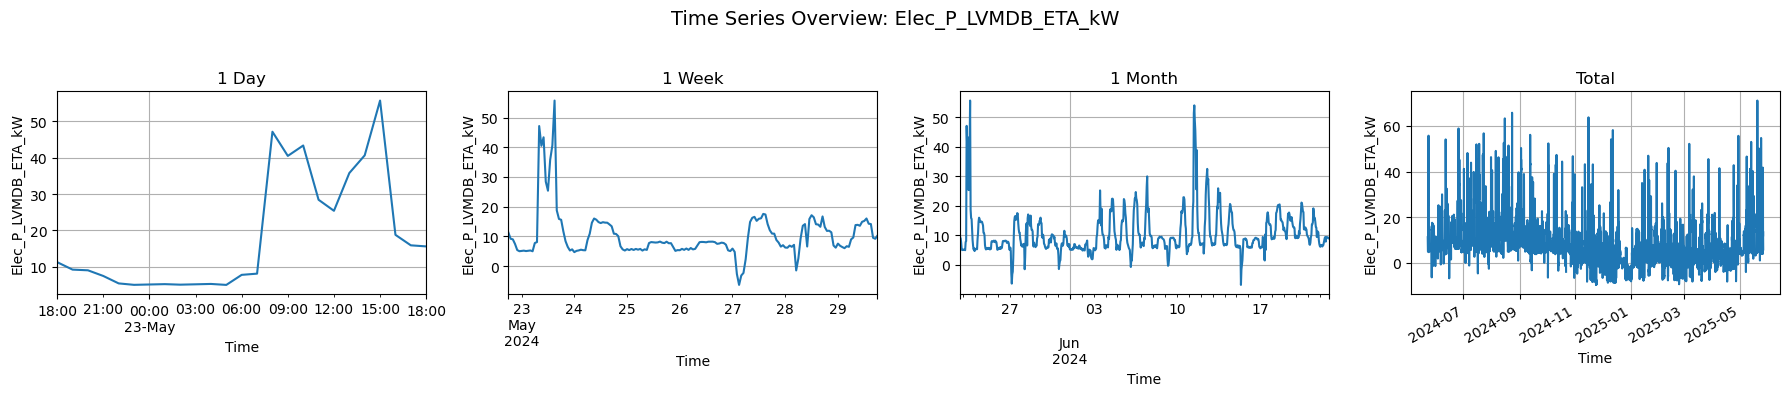

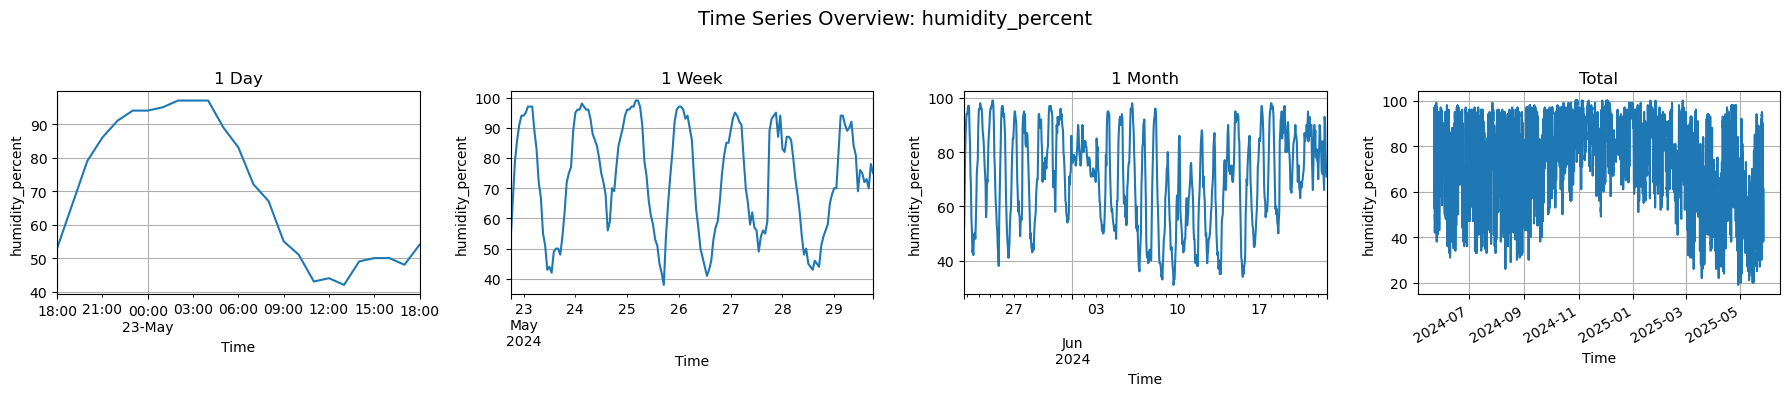

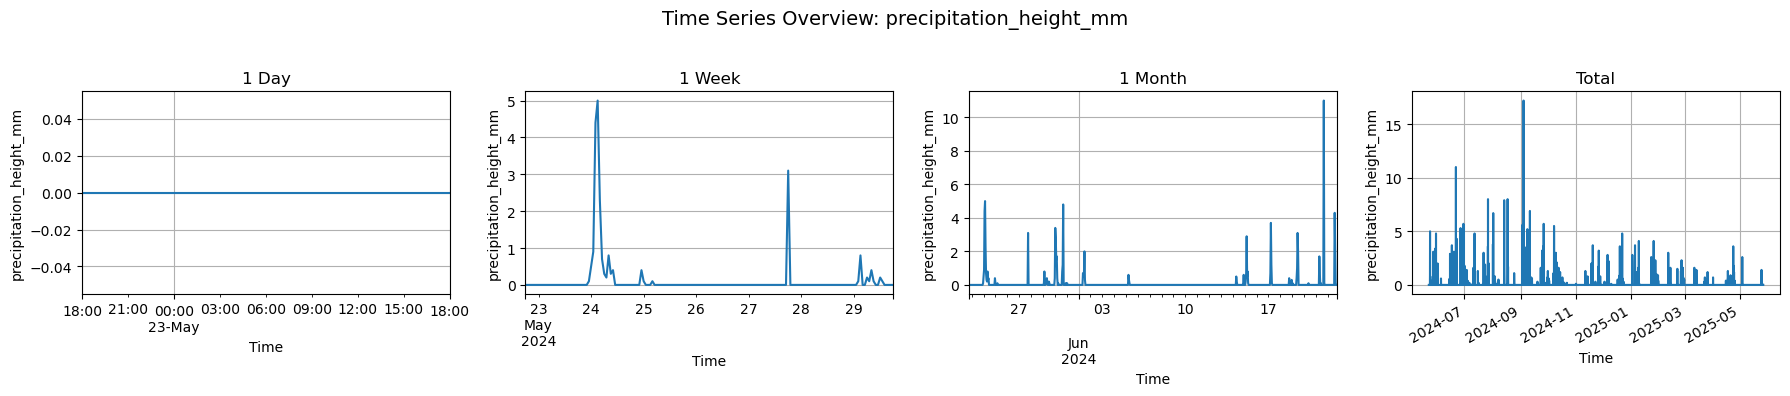

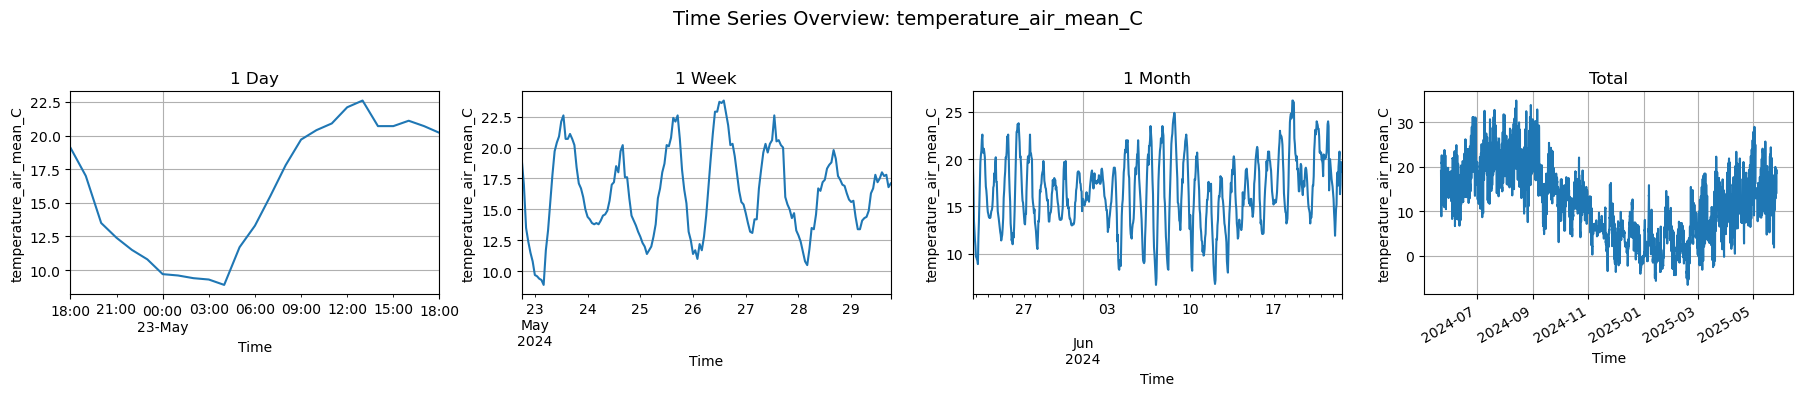

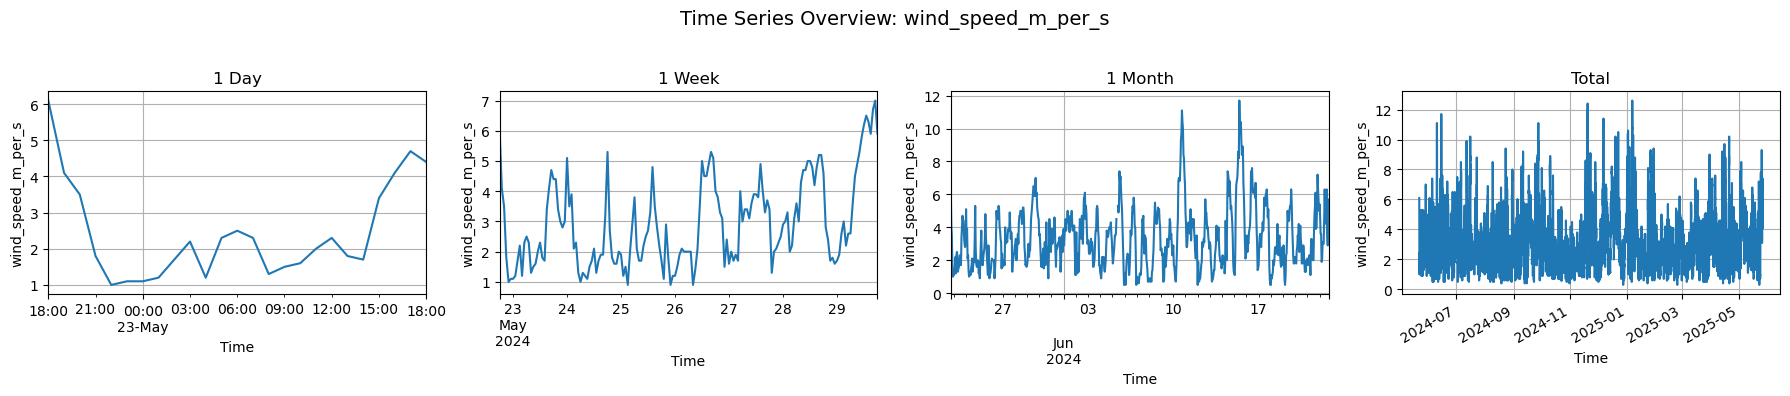

In [9]:
plot_multicolumn_timeseries_overview(train_original)

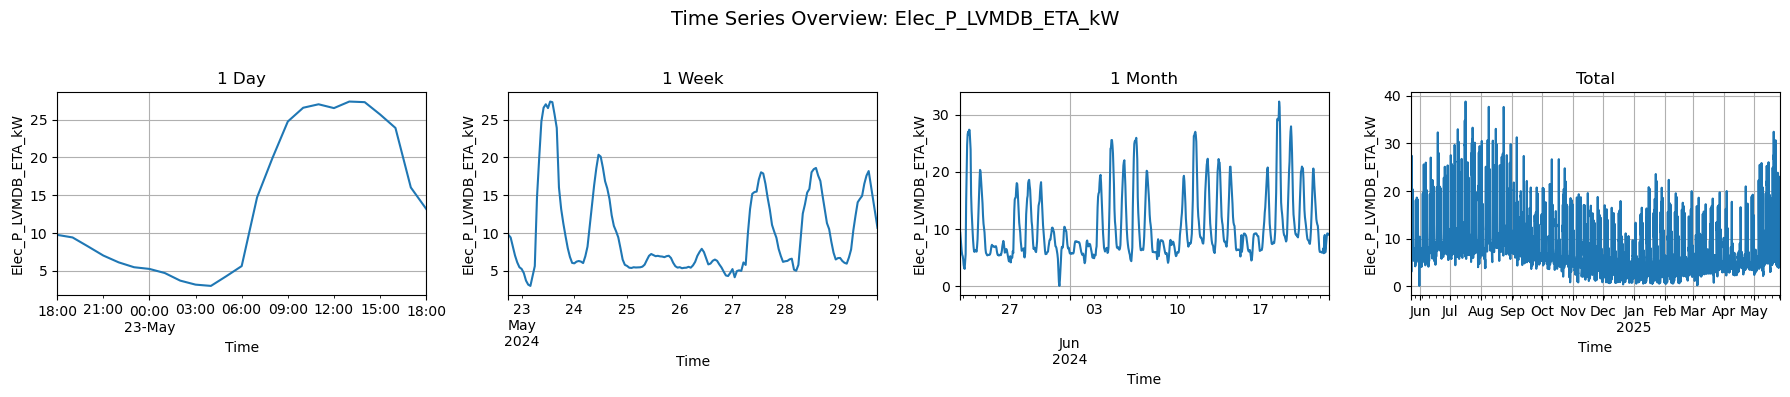

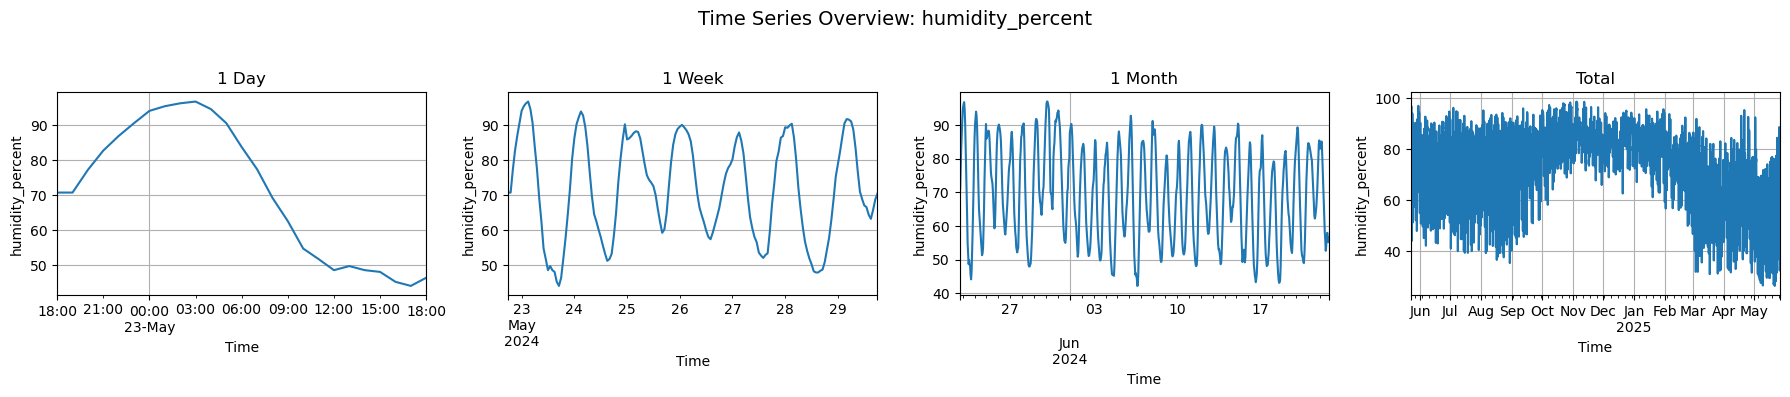

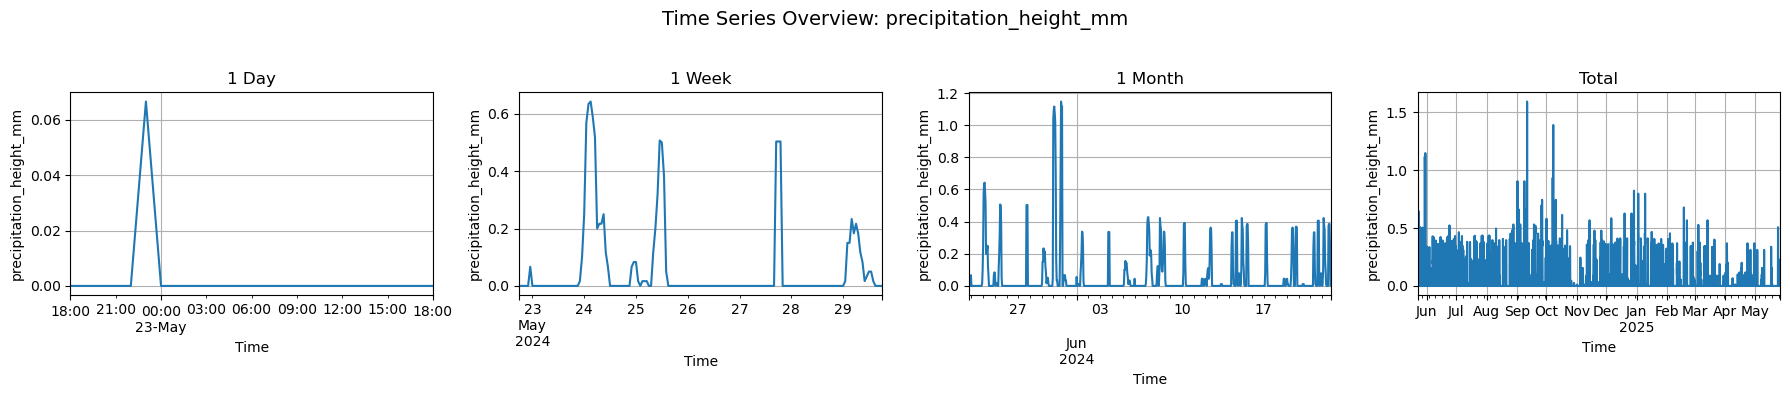

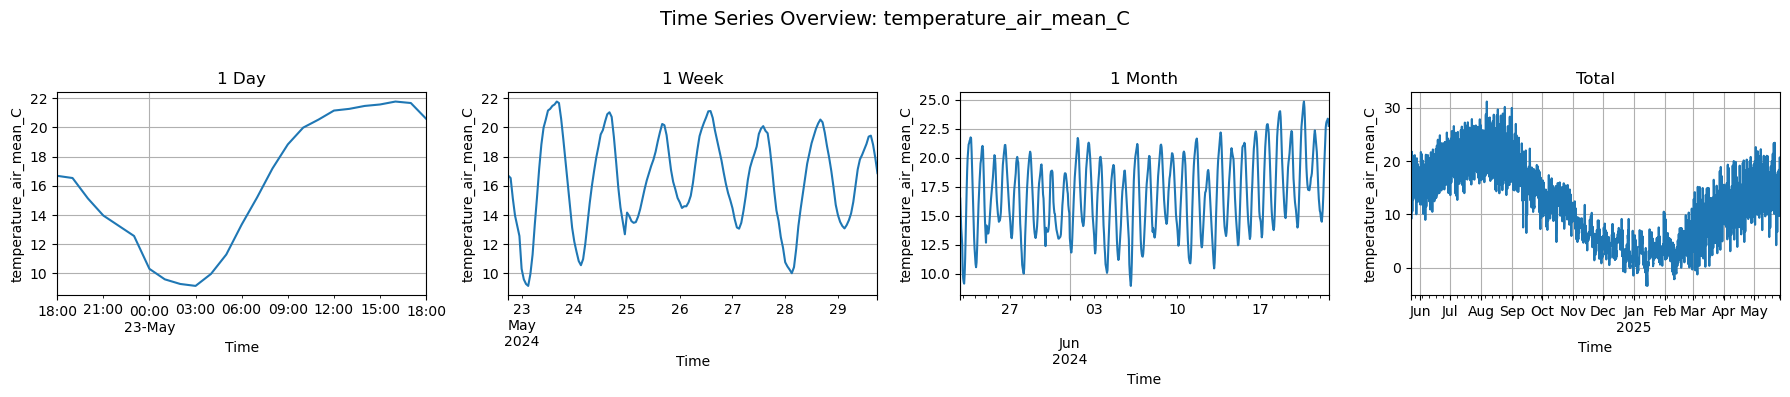

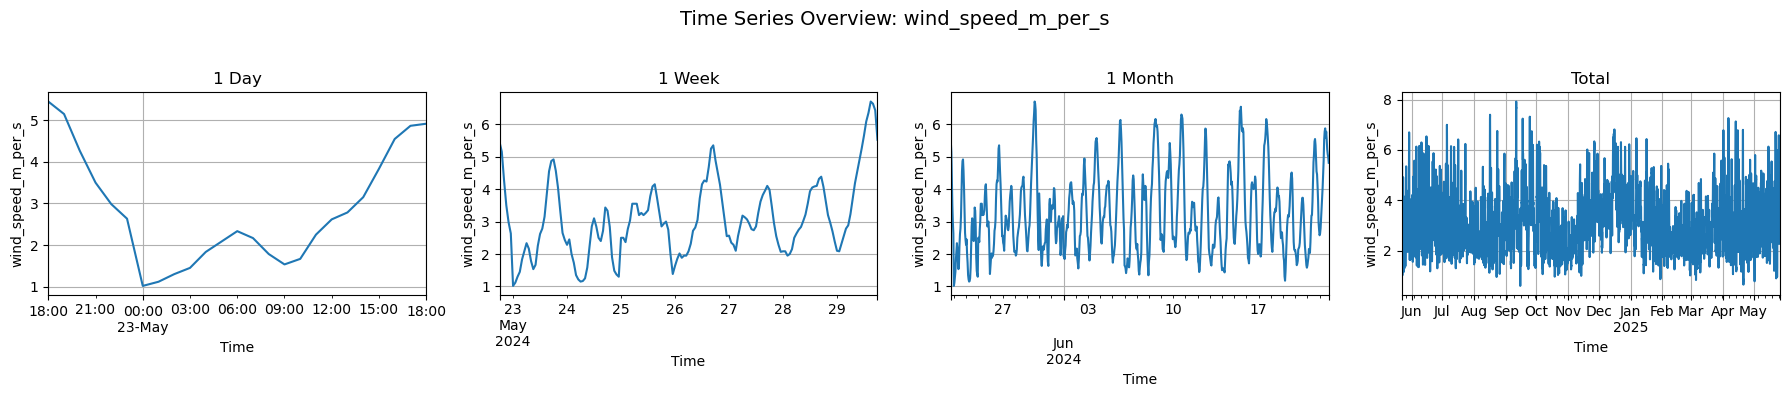

In [10]:
plot_multicolumn_timeseries_overview(train_filtered)

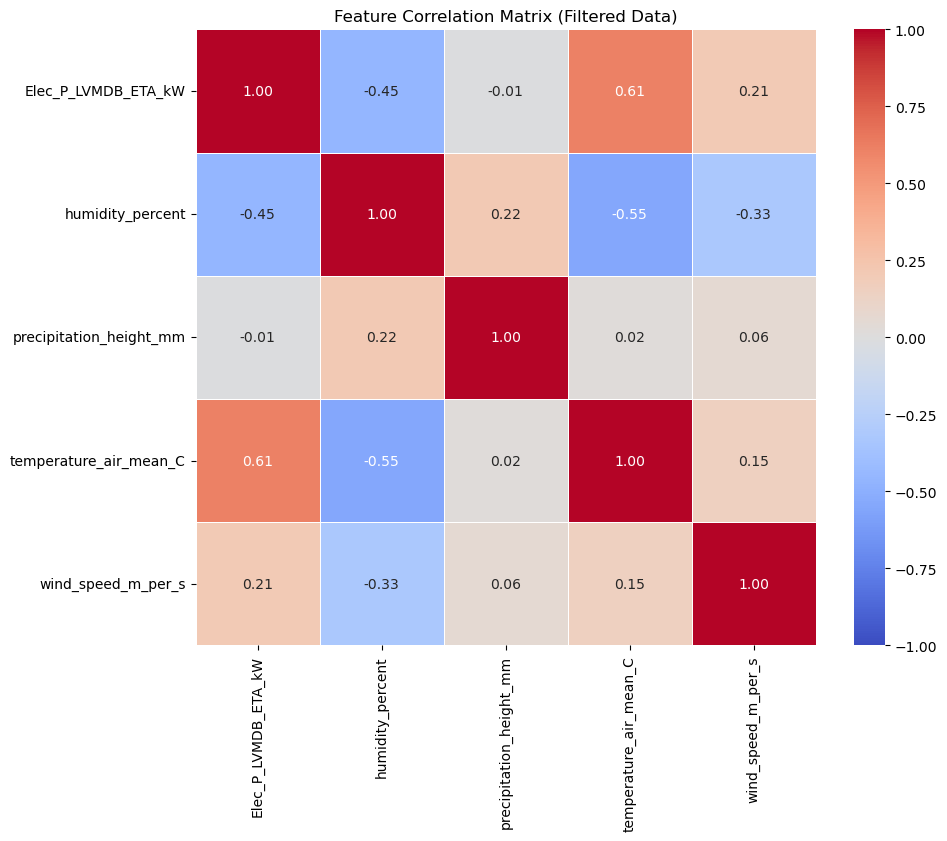

--- Correlation with Elec_P_LVMDB_ETA_kW ---
Elec_P_LVMDB_ETA_kW        1.000000
temperature_air_mean_C     0.614894
wind_speed_m_per_s         0.208269
precipitation_height_mm   -0.011561
humidity_percent          -0.453869
Name: Elec_P_LVMDB_ETA_kW, dtype: float64


In [11]:
# Total correlation
import seaborn as sns
import matplotlib.pyplot as plt

def analyze_correlations(df):
    # 1. Calculate the Correlation Matrix
    corr_matrix = df.corr()

    # 2. Plot the Heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
    plt.title("Feature Correlation Matrix (Filtered Data)")
    plt.show()

    # 3. Print Correlation with Electric Load specifically
    target_col = 'Elec_P_LVMDB_ETA_kW'
    print(f"--- Correlation with {target_col} ---")
    print(corr_matrix[target_col].sort_values(ascending=False))

# Run the function on your filtered data
analyze_correlations(train_filtered)

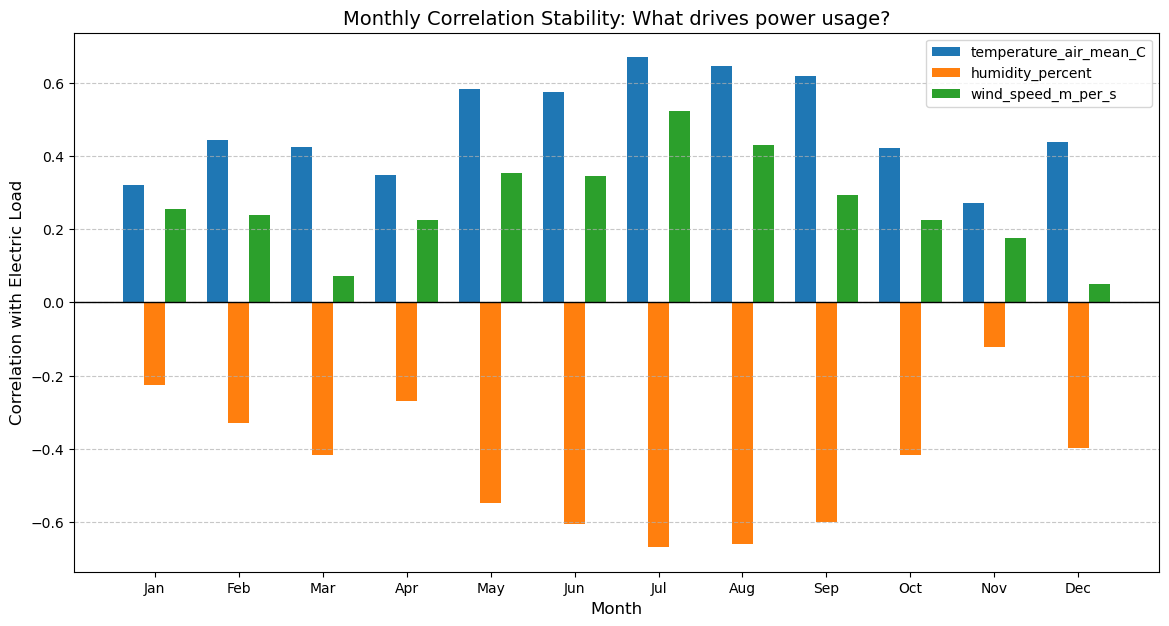


   DETAILED CORRELATION DATA
       temperature_air_mean_C  humidity_percent  wind_speed_m_per_s
Month                                                              
1                       0.319            -0.227               0.254
2                       0.443            -0.329               0.238
3                       0.424            -0.418               0.072
4                       0.347            -0.269               0.225
5                       0.583            -0.547               0.353
6                       0.575            -0.606               0.346
7                       0.669            -0.669               0.522
8                       0.647            -0.661               0.430
9                       0.619            -0.601               0.294
10                      0.422            -0.416               0.224
11                      0.272            -0.122               0.175
12                      0.438            -0.398               0.051

   AI DIAGNOSIS
J

In [12]:
# Monthly Correlation
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def analyze_seasonality_full(df):
    # ---------------------------------------------------------
    # 1. CALCULATE CORRELATIONS
    # ---------------------------------------------------------
    df = df.copy()
    df['Month'] = df.index.month
    
    target = 'Elec_P_LVMDB_ETA_kW'
    features = ['temperature_air_mean_C', 'humidity_percent', 'wind_speed_m_per_s']
    
    # Storage for Plotting and Table
    monthly_data = {feat: [] for feat in features}
    table_rows = []
    months = range(1, 13)
    
    for m in months:
        subset = df[df['Month'] == m]
        # Calculate correlation matrix for this month
        corr_matrix = subset.corr()
        
        row_dict = {'Month': m}
        for feat in features:
            val = 0
            if target in corr_matrix and feat in corr_matrix:
                val = corr_matrix.loc[target, feat]
            
            # Store for plot
            monthly_data[feat].append(val)
            # Store for table
            row_dict[feat] = val
            
        table_rows.append(row_dict)

    # ---------------------------------------------------------
    # 2. GENERATE GRAPH
    # ---------------------------------------------------------
    x = np.arange(len(months))
    width = 0.25
    
    plt.figure(figsize=(14, 7))
    
    # Create bars for each feature
    for i, feat in enumerate(features):
        plt.bar(x + (i * width), monthly_data[feat], width, label=feat)
        
    plt.xlabel('Month', fontsize=12)
    plt.ylabel('Correlation with Electric Load', fontsize=12)
    plt.title('Monthly Correlation Stability: What drives power usage?', fontsize=14)
    plt.xticks(x + width, ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                           'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    plt.axhline(0, color='black', linewidth=1)
    plt.legend(loc='upper right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # ---------------------------------------------------------
    # 3. PRINT TABLE & DIAGNOSIS
    # ---------------------------------------------------------
    results_df = pd.DataFrame(table_rows).set_index('Month')
    
    print("\n" + "="*40)
    print("   DETAILED CORRELATION DATA")
    print("="*40)
    print(results_df.round(3))
    
    # Auto-Diagnosis Logic
    jan_temp = results_df.loc[1, 'temperature_air_mean_C']
    jul_temp = results_df.loc[7, 'temperature_air_mean_C']
    
    print("\n" + "="*40)
    print("   AI DIAGNOSIS")
    print("="*40)
    print(f"Jan Temp Correlation: {jan_temp:.3f}")
    print(f"Jul Temp Correlation: {jul_temp:.3f}")
    
    if jan_temp > 0.1 and jul_temp > 0.1:
        print("VERDICT: [Cooling Dominant] ❄️")
        print("Explanation: Power usage rises with temperature all year (even in winter).")
        print("Likely causes: Server rooms, Industrial process cooling, or warm climate.")
        
    elif jan_temp < -0.1 and jul_temp > 0.1:
        print("VERDICT: [Dual Mode] ❄️🔥")
        print("Explanation: Power rises when it's Hot (AC) AND when it's Cold (Heaters).")
        print("Advice: This is non-linear. Linear Regression will fail unless we split the data.")
        
    else:
        print("VERDICT: [Baseload / Complex]")
        print("Explanation: Weather influence is weak or mixed.")

# Run the combined analysis
analyze_seasonality_full(train_filtered)

In [13]:
train_filtered.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8860 entries, 2024-05-22 18:00:00 to 2025-05-26 21:00:00
Freq: h
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Elec_P_LVMDB_ETA_kW      8860 non-null   float64
 1   humidity_percent         8860 non-null   float64
 2   precipitation_height_mm  8860 non-null   float64
 3   temperature_air_mean_C   8860 non-null   float64
 4   wind_speed_m_per_s       8860 non-null   float64
dtypes: float64(5)
memory usage: 673.4 KB


# 2 Data Engineering

## 2.1. Feature Building

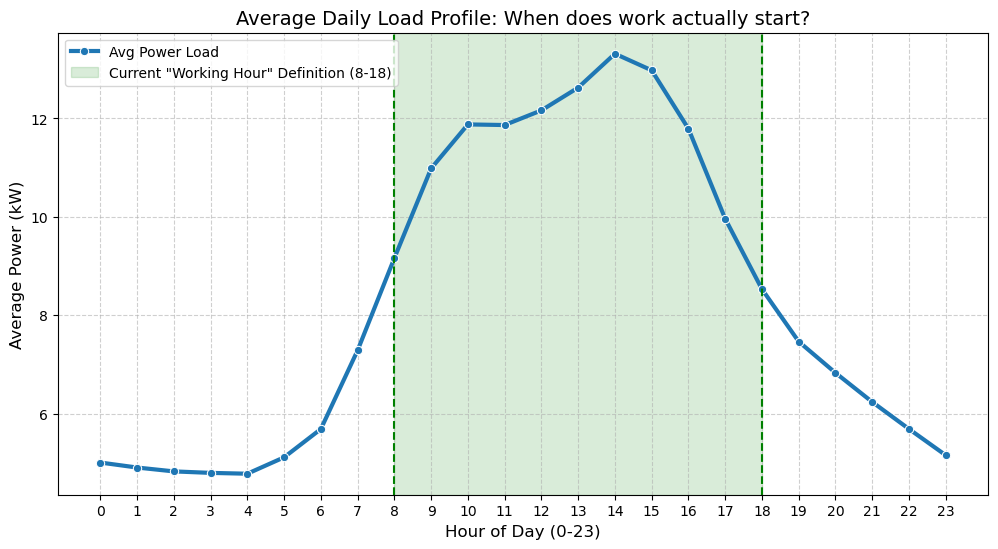

In [14]:
# Checking working hours
import matplotlib.pyplot as plt
import seaborn as sns

def verify_working_hours(df):
    # 1. Group by Hour to get the "Average Day"
    hourly_profile = df.groupby(df.index.hour)['Elec_P_LVMDB_ETA_kW'].mean()
    
    # 2. Plotting
    plt.figure(figsize=(12, 6))
    
    # Plot the line
    sns.lineplot(x=hourly_profile.index, y=hourly_profile.values, marker='o', linewidth=3, label='Avg Power Load')
    
    # 3. Visualize the "Working Hours" I selected (8 AM - 6 PM)
    # Highlight the area I currently marked as "Working Hour"
    plt.axvspan(8, 18, color='green', alpha=0.15, label='Current "Working Hour" Definition (8-18)')
    
    # Add vertical lines for boundaries
    plt.axvline(8, color='green', linestyle='--')
    plt.axvline(18, color='green', linestyle='--')
    
    plt.title('Average Daily Load Profile: When does work actually start?', fontsize=14)
    plt.xlabel('Hour of Day (0-23)', fontsize=12)
    plt.ylabel('Average Power (kW)', fontsize=12)
    plt.xticks(range(0, 24))
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

verify_working_hours(train_filtered)

In [15]:
import pandas as pd
import numpy as np
import holidays
from dateutil.easter import easter

def feature_engineering(df):
    df = df.copy()
    
    # ---------------------------------------------------------
    # STEP 1: SETUP
    # ---------------------------------------------------------
    years = list(range(df.index.year.min(), df.index.year.max() + 2))
    lib_holidays = holidays.DE(years=years, prov='HE') 
    
    # Learn Closed Days (Low Load)
    if 'day_status' in df.columns:
        closed_mask = (df['day_status'] == 'closed') & (df.index.dayofweek < 5)
        data_holidays_dates = df[closed_mask].index.normalize().unique().tolist()
    else:
        if 'Elec_P_LVMDB_ETA_kW' in df.columns:
            daily_max = df['Elec_P_LVMDB_ETA_kW'].resample('D').max()
            # Threshold 12.0 kW for 'Closed'
            closed_days = daily_max[daily_max < 12.0].index
            data_holidays_dates = [d for d in closed_days if d.dayofweek < 5]
        else:
            data_holidays_dates = []

    data_holidays_set = set(d.date() for d in data_holidays_dates)

    # Filter Library Holidays (Keep only confirmed)
    confirmed_event_names = set()
    train_start = df.index.min().date()
    train_end = df.index.max().date()
    for date, name in lib_holidays.items():
        if train_start <= date <= train_end:
            if date in data_holidays_set:
                confirmed_event_names.add(name)
    
    # Learn Fixed Dates
    fixed_dates = set()
    for date in data_holidays_set:
        if date not in lib_holidays:
            fixed_dates.add((date.month, date.day))
    # Safety: Hardcode known fixed shutdowns
    fixed_dates.update([(12, 24), (12, 27), (12, 28), (12, 29), (12, 30), (12, 31)])

    # Holy Week Rule
    def is_holy_week_shutdown(ts):
        curr_easter = pd.Timestamp(easter(ts.year))
        good_friday = curr_easter - pd.Timedelta(days=2)
        start = curr_easter - pd.Timedelta(days=6)
        if start.date() <= ts.date() < good_friday.date():
            return True
        return False

    # ---------------------------------------------------------
    # STEP 2: CREATE EXPLICIT FEATURES
    # ---------------------------------------------------------
    def get_features(ts):
        # 1. is_working_day (Strictly Mon-Fri)
        # User requirement: "Working day should give 1 for Mon-fri and 0 for sat-sun"
        is_working = 1 if ts.dayofweek < 5 else 0
        
        # 2. is_holiday (Library OR Fixed OR Holy Week)
        is_hol = 0
        if ts.date() in lib_holidays:
            if lib_holidays[ts.date()] in confirmed_event_names:
                is_hol = 1
        if (ts.month, ts.day) in fixed_dates:
            is_hol = 1
        if is_holy_week_shutdown(ts):
            is_hol = 1
            
        # 3. is_working_sunday (15th Rule)
        is_ws = 0
        if (ts.day == 15) and (ts.dayofweek == 6):
            if ts.month not in [12, 1, 2]:
                is_ws = 1
        
        return pd.Series([is_working, is_hol, is_ws])

    # Apply Logic
    feat_cols = df.index.to_series().apply(get_features)
    feat_cols.columns = ['is_working_day', 'is_holiday', 'is_working_sunday']
    df = pd.concat([df, feat_cols], axis=1)

    # Tomorrow Features
    next_cols = df.index.to_series().apply(lambda x: get_features(x + pd.Timedelta(days=1)))
    next_cols.columns = ['next_is_working', 'next_is_holiday', 'next_is_ws']
    df = pd.concat([df, next_cols], axis=1)

    # ---------------------------------------------------------
    # STEP 3: TIME & LAGS
    # ---------------------------------------------------------
    df['hour'] = df.index.hour
    df['day_of_week'] = df.index.dayofweek
    df['day'] = df.index.day
    df['month'] = df.index.month
    df['day_of_year'] = df.index.dayofyear
    
    # Explicitly creating lags 1-5 ONLY (No 24, 48, 168)
    target = 'Elec_P_LVMDB_ETA_kW'
    if target in df.columns:
        for lag in range(1, 6):
            df[f'lag_{lag}h'] = df[target].shift(lag)
    
    # ---------------------------------------------------------
    # STEP 4: CLEANUP
    # ---------------------------------------------------------
    df = df.dropna()
    cols_to_drop = ['day_status', 'precipitation_height_mm'] # Keep is_holiday/ws
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
    
    return df

# Apply it to your filtered data
print("Applying Feature Engineering...")
train_features = feature_engineering(train_filtered)

# Verify the Lags are correct
print("\nVerifying Lags (Past Data Check):")
# Show specific columns to prove lag_1h is the previous hour's actual value
print(train_features[['Elec_P_LVMDB_ETA_kW', 'lag_1h', 'lag_2h']].head())

train_features.head()

Applying Feature Engineering...

Verifying Lags (Past Data Check):
                     Elec_P_LVMDB_ETA_kW    lag_1h    lag_2h
Time                                                        
2024-05-22 23:00:00             5.482079  6.126617  7.029721
2024-05-23 00:00:00             5.258187  5.482079  6.126617
2024-05-23 01:00:00             4.714096  5.258187  5.482079
2024-05-23 02:00:00             3.710839  4.714096  5.258187
2024-05-23 03:00:00             3.179700  3.710839  4.714096


,Elec_P_LVMDB_ETA_kW,humidity_percent,temperature_air_mean_C,wind_speed_m_per_s,is_working_day,is_holiday,is_working_sunday,next_is_working,next_is_holiday,next_is_ws,hour,day_of_week,day,month,day_of_year,lag_1h,lag_2h,lag_3h,lag_4h,lag_5h
Time,,,,,,,,,,,,,,,,,,,,
2024-05-22 23:00:00,5.482079,90.666667,12.566667,2.633333,1,1,0,1,0,0,23,2,22,5,143,6.126617,7.029721,8.240440,9.423022,9.764085
2024-05-23 00:00:00,5.258187,94.166667,10.316667,1.016667,1,0,0,1,0,0,0,3,23,5,144,5.482079,6.126617,7.029721,8.240440,9.423022
2024-05-23 01:00:00,4.714096,95.500000,9.600000,1.116667,1,0,0,1,0,0,1,3,23,5,144,5.258187,5.482079,6.126617,7.029721,8.240440
2024-05-23 02:00:00,3.710839,96.333333,9.283333,1.300000,1,0,0,1,0,0,2,3,23,5,144,4.714096,5.258187,5.482079,6.126617,7.029721
2024-05-23 03:00:00,3.179700,96.833333,9.150000,1.450000,1,0,0,1,0,0,3,3,23,5,144,3.710839,4.714096,5.258187,5.482079,6.126617


In [16]:
train_features.describe()

,Elec_P_LVMDB_ETA_kW,humidity_percent,temperature_air_mean_C,wind_speed_m_per_s,is_working_day,is_holiday,is_working_sunday,next_is_working,next_is_holiday,next_is_ws,hour,day_of_week,day,month,day_of_year,lag_1h,lag_2h,lag_3h,lag_4h,lag_5h
count,8855.000000,8855.000000,8855.000000,8855.000000,8855.000000,8855.000000,8855.000000,8855.000000,8855.000000,8855.000000,8855.000000,8855.000000,8855.000000,8855.000000,8855.000000,8855.000000,8855.000000,8855.000000,8855.000000,8855.000000
mean,8.293876,72.155624,11.913001,3.170312,0.712705,0.176285,0.002710,0.712705,0.176172,0.002710,11.498814,3.008696,15.814116,6.509656,183.190853,8.293895,8.293937,8.293797,8.293411,8.292759
std,5.783672,15.901213,7.292988,1.155022,0.452526,0.381084,0.051993,0.452526,0.380988,0.051993,6.922069,2.001759,8.796228,3.433102,105.292418,5.783665,5.783655,5.783641,5.783452,5.782961
min,0.032340,26.500000,-3.450000,0.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.032340,0.032340,0.032340,0.032340,0.032340
25%,4.562039,60.888889,5.477778,2.277778,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.500000,1.000000,8.000000,4.000000,93.000000,4.562039,4.562039,4.562039,4.562039,4.562039
50%,6.560940,76.111111,11.888889,3.033333,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.000000,3.000000,16.000000,6.000000,182.000000,6.560940,6.560940,6.560940,6.560940,6.560940
75%,10.348690,84.777778,17.577778,3.888889,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,17.000000,5.000000,23.000000,9.000000,274.000000,10.348690,10.348690,10.348690,10.344759,10.342758
max,38.822153,98.666667,31.188889,7.923679,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,23.000000,6.000000,31.000000,12.000000,366.000000,38.822153,38.822153,38.822153,38.822153,38.822153


In [17]:
train_features.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8855 entries, 2024-05-22 23:00:00 to 2025-05-26 21:00:00
Freq: h
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Elec_P_LVMDB_ETA_kW     8855 non-null   float64
 1   humidity_percent        8855 non-null   float64
 2   temperature_air_mean_C  8855 non-null   float64
 3   wind_speed_m_per_s      8855 non-null   float64
 4   is_working_day          8855 non-null   int64  
 5   is_holiday              8855 non-null   int64  
 6   is_working_sunday       8855 non-null   int64  
 7   next_is_working         8855 non-null   int64  
 8   next_is_holiday         8855 non-null   int64  
 9   next_is_ws              8855 non-null   int64  
 10  hour                    8855 non-null   int32  
 11  day_of_week             8855 non-null   int32  
 12  day                     8855 non-null   int32  
 13  month                   8855 non-null   int32  
 

## 2.2. Target Generation

In [18]:
import pandas as pd
import numpy as np

def prepare_multi_output_data(df):
    df = df.copy()
    
    # ---------------------------------------------------------
    # 1. CREATE TARGETS (Next 24 Hours)
    # ---------------------------------------------------------
    # We want to predict t+1, t+2, ... t+24
    target_col = 'Elec_P_LVMDB_ETA_kW'
    
    # Create 24 new columns for the future loads
    target_cols = []
    for i in range(1, 25):
        col_name = f'target_h{i}'
        df[col_name] = df[target_col].shift(-i) # Shift negative looks into Future
        target_cols.append(col_name)
        
    # ---------------------------------------------------------
    # 2. HANDLE MISSING DATA (Trimming)
    # ---------------------------------------------------------
    # 'shift(-24)' creates NaNs at the END of the data
    # 'shift(5)' (from lag features) created NaNs at the START
    # We drop ANY row that has a NaN in either Features or Targets
    df_final = df.dropna()
    
    # ---------------------------------------------------------
    # 3. SEPARATE FEATURES (X) AND TARGETS (y)
    # ---------------------------------------------------------
    # Features: All original columns (including current Load) MINUS the new target columns
    feature_cols = [c for c in df_final.columns if c not in target_cols]
    
    X = df_final[feature_cols]
    y = df_final[target_cols]
    
    return X, y

# Run the preparation
print("Preparing Multi-Output Data (Next 24 Hours)...")
X, y = prepare_multi_output_data(train_features)

# ---------------------------------------------------------
# VERIFICATION
# ---------------------------------------------------------
print("\nDimensions Check:")
print(f"Features (X) Shape: {X.shape}")
print(f"Targets  (y) Shape: {y.shape}")

print("\nFeature List (X):")
print(X.columns.tolist())

print("\nTarget Sample (y) - First Row:")
print(y.iloc[0, :5], "... up to target_h24")

# Verification Logic
if len(X) == len(y):
    print("\n✅ Success: X and y have the same number of rows.")
else:
    print("\n❌ Error: X and y length mismatch!")

Preparing Multi-Output Data (Next 24 Hours)...

Dimensions Check:
Features (X) Shape: (8831, 20)
Targets  (y) Shape: (8831, 24)

Feature List (X):
['Elec_P_LVMDB_ETA_kW', 'humidity_percent', 'temperature_air_mean_C', 'wind_speed_m_per_s', 'is_working_day', 'is_holiday', 'is_working_sunday', 'next_is_working', 'next_is_holiday', 'next_is_ws', 'hour', 'day_of_week', 'day', 'month', 'day_of_year', 'lag_1h', 'lag_2h', 'lag_3h', 'lag_4h', 'lag_5h']

Target Sample (y) - First Row:
target_h1    5.258187
target_h2    4.714096
target_h3    3.710839
target_h4    3.179700
target_h5    3.011345
Name: 2024-05-22 23:00:00, dtype: float64 ... up to target_h24

✅ Success: X and y have the same number of rows.


In [19]:
X.head()

,Elec_P_LVMDB_ETA_kW,humidity_percent,temperature_air_mean_C,wind_speed_m_per_s,is_working_day,is_holiday,is_working_sunday,next_is_working,next_is_holiday,next_is_ws,hour,day_of_week,day,month,day_of_year,lag_1h,lag_2h,lag_3h,lag_4h,lag_5h
Time,,,,,,,,,,,,,,,,,,,,
2024-05-22 23:00:00,5.482079,90.666667,12.566667,2.633333,1,1,0,1,0,0,23,2,22,5,143,6.126617,7.029721,8.240440,9.423022,9.764085
2024-05-23 00:00:00,5.258187,94.166667,10.316667,1.016667,1,0,0,1,0,0,0,3,23,5,144,5.482079,6.126617,7.029721,8.240440,9.423022
2024-05-23 01:00:00,4.714096,95.500000,9.600000,1.116667,1,0,0,1,0,0,1,3,23,5,144,5.258187,5.482079,6.126617,7.029721,8.240440
2024-05-23 02:00:00,3.710839,96.333333,9.283333,1.300000,1,0,0,1,0,0,2,3,23,5,144,4.714096,5.258187,5.482079,6.126617,7.029721
2024-05-23 03:00:00,3.179700,96.833333,9.150000,1.450000,1,0,0,1,0,0,3,3,23,5,144,3.710839,4.714096,5.258187,5.482079,6.126617


In [20]:
y.head()

,target_h1,target_h2,target_h3,target_h4,target_h5,target_h6,target_h7,target_h8,target_h9,target_h10,...,target_h15,target_h16,target_h17,target_h18,target_h19,target_h20,target_h21,target_h22,target_h23,target_h24
Time,,,,,,,,,,,,,,,,,,,,,
2024-05-22 23:00:00,5.258187,4.714096,3.710839,3.179700,3.011345,4.297552,5.633174,14.719412,19.924032,24.760022,...,27.321038,25.695880,23.909571,16.033822,13.196840,11.263236,9.588056,8.012273,6.845152,6.056679
2024-05-23 00:00:00,4.714096,3.710839,3.179700,3.011345,4.297552,5.633174,14.719412,19.924032,24.760022,26.582248,...,25.695880,23.909571,16.033822,13.196840,11.263236,9.588056,8.012273,6.845152,6.056679,5.995674
2024-05-23 01:00:00,3.710839,3.179700,3.011345,4.297552,5.633174,14.719412,19.924032,24.760022,26.582248,27.040035,...,23.909571,16.033822,13.196840,11.263236,9.588056,8.012273,6.845152,6.056679,5.995674,6.222973
2024-05-23 02:00:00,3.179700,3.011345,4.297552,5.633174,14.719412,19.924032,24.760022,26.582248,27.040035,26.534823,...,16.033822,13.196840,11.263236,9.588056,8.012273,6.845152,6.056679,5.995674,6.222973,6.306610
2024-05-23 03:00:00,3.011345,4.297552,5.633174,14.719412,19.924032,24.760022,26.582248,27.040035,26.534823,27.401405,...,13.196840,11.263236,9.588056,8.012273,6.845152,6.056679,5.995674,6.222973,6.306610,6.229820


# 3. Modeling

## 3.1. Data spliting

In [21]:
from sklearn.model_selection import train_test_split

# ---------------------------------------------------------
# 1. PREPARE X AND y (MULTI-STEP)
# ---------------------------------------------------------
# We use the function we defined previously: prepare_multi_output_data
# X contains Current Load + Weather + Lags + Time Features
# y contains Next 24 hours of Load
X, y = prepare_multi_output_data(train_features)

# ---------------------------------------------------------
# 2. TIME-BASED SPLIT
# ---------------------------------------------------------
# We cannot use random shuffling for Time Series!
split_point = int(len(X) * 0.80)

X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

print(f"Training Data: {X_train.shape} samples")
print(f"Testing Data:  {X_test.shape} samples")

Training Data: (7064, 20) samples
Testing Data:  (1767, 20) samples


In [22]:
testX0 = pd.read_csv("Data/my_example_slices/test_X_slice_0.csv")
testY0 = pd.read_csv("Data/my_example_slices/test_Y_slice_0.csv")

testX0['Time'] = pd.to_datetime(testX0['Time'])
testX0 = testX0.drop_duplicates(subset='Time').set_index('Time').sort_index()
testX0.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 24 entries, 2025-06-14 07:00:00 to 2025-06-15 06:00:00
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Elec_P_LVMDB_ETA_kW      24 non-null     float64
 1   humidity_percent         24 non-null     float64
 2   precipitation_height_mm  24 non-null     float64
 3   temperature_air_mean_C   24 non-null     float64
 4   wind_speed_m_per_s       24 non-null     float64
dtypes: float64(5)
memory usage: 1.1 KB


In [23]:
testX0 = feature_engineering(testX0)
testX0.head()

,Elec_P_LVMDB_ETA_kW,humidity_percent,temperature_air_mean_C,wind_speed_m_per_s,is_working_day,is_holiday,is_working_sunday,next_is_working,next_is_holiday,next_is_ws,hour,day_of_week,day,month,day_of_year,lag_1h,lag_2h,lag_3h,lag_4h,lag_5h
Time,,,,,,,,,,,,,,,,,,,,
2025-06-14 12:00:00,6.222002,32.0,32.2,2.8,0,0,0,0,0,1,12,5,14,6,165,6.172391,6.195837,6.296426,6.224872,5.856867
2025-06-14 13:00:00,6.236807,30.0,32.4,4.7,0,0,0,0,0,1,13,5,14,6,165,6.222002,6.172391,6.195837,6.296426,6.224872
2025-06-14 14:00:00,6.293792,33.0,33.2,4.6,0,0,0,0,0,1,14,5,14,6,165,6.236807,6.222002,6.172391,6.195837,6.296426
2025-06-14 15:00:00,6.306773,35.0,32.7,4.8,0,0,0,0,0,1,15,5,14,6,165,6.293792,6.236807,6.222002,6.172391,6.195837
2025-06-14 16:00:00,6.303000,38.0,33.0,5.7,0,0,0,0,0,1,16,5,14,6,165,6.306773,6.293792,6.236807,6.222002,6.172391


In [24]:
testX0.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 19 entries, 2025-06-14 12:00:00 to 2025-06-15 06:00:00
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Elec_P_LVMDB_ETA_kW     19 non-null     float64
 1   humidity_percent        19 non-null     float64
 2   temperature_air_mean_C  19 non-null     float64
 3   wind_speed_m_per_s      19 non-null     float64
 4   is_working_day          19 non-null     int64  
 5   is_holiday              19 non-null     int64  
 6   is_working_sunday       19 non-null     int64  
 7   next_is_working         19 non-null     int64  
 8   next_is_holiday         19 non-null     int64  
 9   next_is_ws              19 non-null     int64  
 10  hour                    19 non-null     int32  
 11  day_of_week             19 non-null     int32  
 12  day                     19 non-null     int32  
 13  month                   19 non-null     int32  
 14  day_of

In [25]:
testY0 = testY0["Elec_P_LVMDB_ETA_kW"]

In [26]:
testY0.info()

<class 'pandas.core.series.Series'>
RangeIndex: 24 entries, 0 to 23
Series name: Elec_P_LVMDB_ETA_kW
Non-Null Count  Dtype  
--------------  -----  
24 non-null     float64
dtypes: float64(1)
memory usage: 324.0 bytes


## 3.2 Model functions

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.dates as mdates
from sklearn.metrics import mean_squared_error, r2_score

# =========================================================
# 1. DIAGNOSTIC PLOTS (Robust)
# =========================================================
def plot_diagnostics(y_true, y_pred, title):
    """
    Generates Scatter Plot and Residual Analysis.
    Calculates a 'Global R2' by flattening the data.
    """
    # Flatten arrays
    if hasattr(y_true, 'values'): y_true_flat = y_true.values.flatten()
    else: y_true_flat = np.array(y_true).flatten()
    y_pred_flat = np.array(y_pred).flatten()
    
    # Align lengths
    min_len = min(len(y_true_flat), len(y_pred_flat))
    y_true_flat = y_true_flat[:min_len]
    y_pred_flat = y_pred_flat[:min_len]
    
    residuals = y_true_flat - y_pred_flat
    
    # Calculate Global R2 (Shape Accuracy)
    # This WORKS for TestX0 because we treat the 24 hours as 24 points
    r2_val = r2_score(y_true_flat, y_pred_flat)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # --- Scatter Plot ---
    axes[0].scatter(y_true_flat, y_pred_flat, alpha=0.5, s=10, color='blue')
    min_val = min(y_true_flat.min(), y_pred_flat.min())
    max_val = max(y_true_flat.max(), y_pred_flat.max())
    axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Fit')
    
    axes[0].set_xlabel("Actual Load (kW)")
    axes[0].set_ylabel("Predicted Load (kW)")
    axes[0].set_title(f"Scatter: Actual vs Predicted\nGlobal R²: {r2_val:.4f}")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # --- Residual Plot ---
    axes[1].scatter(y_pred_flat, residuals, alpha=0.5, s=10, color='purple')
    axes[1].axhline(0, color='red', linestyle='--', lw=2)
    axes[1].set_xlabel("Predicted Load (kW)")
    axes[1].set_ylabel("Residuals (Actual - Predicted)")
    axes[1].set_title(f"Residual Analysis\nMean Error: {np.mean(residuals):.4f}")
    axes[1].grid(True, alpha=0.3)
    
    plt.suptitle(f"{title} Diagnostics", fontsize=14)
    plt.tight_layout()
    plt.show()

def plot_combined_r2(y_train_true, y_train_pred, y_test_true, y_test_pred, title="Combined R2 Score vs Horizon"):
    """
    Plots R2 scores per horizon step (1h to 24h).
    """
    # Determine forecast horizon
    if hasattr(y_train_true, 'shape'): horizon = y_train_true.shape[1]
    else: horizon = len(y_train_true[0])
    
    r2_train = []
    r2_test = []
    
    for i in range(horizon):
        col_tr = y_train_true.iloc[:, i] if hasattr(y_train_true, 'iloc') else y_train_true[:, i]
        col_te = y_test_true.iloc[:, i] if hasattr(y_test_true, 'iloc') else y_test_true[:, i]
        
        r2_train.append(r2_score(col_tr, y_train_pred[:, i]))
        r2_test.append(r2_score(col_te, y_test_pred[:, i]))
        
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, horizon + 1), r2_train, 'bo-', linewidth=2, label='Training Data')
    plt.plot(range(1, horizon + 1), r2_test, 'rx--', linewidth=2, label='Test Data')
    
    plt.xlabel("Forecasting Horizon (Hours Ahead)")
    plt.ylabel("R2 Score")
    plt.title(title)
    plt.xticks(range(1, horizon + 1))
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 1.05)
    plt.legend()
    plt.show()

MAE_test_models = {}

# =========================================================
# 1. ROBUST FLOW PLOTTER (Fixed for Multi-Output Targets)
# =========================================================
def plot_flow_labeled(model, X_data, y_data, title, specific_day=None, specific_hour=None):
    # --- A. DETECT TYPE (DataFrame or Array?) ---
    is_df = isinstance(X_data, pd.DataFrame)
    
    # Get Timestamps (Try X first, then y)
    timestamps = None
    if is_df:
        timestamps = X_data.index
    elif hasattr(y_data, 'index'):
        timestamps = y_data.index
    
    # --- B. FIND INDEX TO PLOT ---
    idx = -1
    if specific_day and timestamps is not None:
        day_map = {'Monday':0, 'Tuesday':1, 'Wednesday':2, 'Thursday':3, 'Friday':4, 'Saturday':5, 'Sunday':6}
        target = day_map.get(specific_day, 0)
        # Search middle of dataset
        start_search = 48
        end_search = len(X_data) - 48
        for i in range(start_search, end_search):
            ts = timestamps[i]
            if ts.dayofweek == target and ts.hour == specific_hour:
                idx = i
                break
    
    if idx == -1: idx = 50 # Fallback safety
    
    # --- C. PREPARE DATA ---
    # 1. Prediction
    if is_df:
        row_slice = X_data.iloc[[idx]]
    else:
        row_slice = X_data[idx:idx+1]
        
    pred_vals = model.predict(row_slice).flatten()
    
    # 2. History (The Input Line)
    # CRITICAL FIX: Handle Multi-Output y_data (N x 24)
    if is_df and 'Elec_P_LVMDB_ETA_kW' in X_data.columns:
        # Use feature if available
        hist_vals = X_data['Elec_P_LVMDB_ETA_kW'].iloc[idx-24:idx].values
    else:
        # Fallback: Reconstruct history from previous target values
        # We need the 0-th column (t+1) from the previous 24 steps
        if isinstance(y_data, (pd.DataFrame, pd.Series)):
            if y_data.ndim > 1 and y_data.shape[1] > 1:
                hist_vals = y_data.iloc[idx-24:idx, 0].values # Take 1st column
            else:
                hist_vals = y_data.iloc[idx-24:idx].values.flatten()
        else:
            # Numpy Array case
            if y_data.ndim > 1 and y_data.shape[1] > 1:
                hist_vals = y_data[idx-24:idx, 0] # Take 1st column
            else:
                hist_vals = y_data[idx-24:idx].flatten()

    # 3. Truth (Future)
    if isinstance(y_data, (pd.DataFrame, pd.Series)):
        true_vals = y_data.iloc[idx].values.flatten()
    else:
        true_vals = y_data[idx].flatten()

    # --- D. TIME AXIS ---
    start_time = timestamps[idx] if timestamps is not None else pd.Timestamp.now()
    
    hist_times = [start_time - pd.Timedelta(hours=h) for h in range(24, 0, -1)]
    fut_times = [start_time + pd.Timedelta(hours=h) for h in range(1, 25)]

    # Metrics
    mae = mean_absolute_error(true_vals, pred_vals)

    # --- E. PLOT ---
    fig, ax = plt.subplots(figsize=(12, 5))
    
    # Only plot history if shapes match
    if len(hist_vals) == len(hist_times):
        ax.plot(hist_times, hist_vals, 'o-', color='grey', alpha=0.5, label='History (Input)')
        # Connect history to future
        if len(true_vals) > 0:
            ax.plot([hist_times[-1], fut_times[0]], [hist_vals[-1], true_vals[0]], '-', color='black', alpha=0.5)
    
    ax.plot(fut_times, true_vals, 'ko-', label='Actual Future')
    ax.plot(fut_times, pred_vals, 'bx--', linewidth=2, label='Predicted Future')
    
    # Formatting
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%A\n%H:%M'))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
    
    ax.set_title(f"{title}\nMAE: {mae:.2f} kW")
    ax.set_ylabel("Load (kW)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# =========================================================
# 2. ROBUST FINAL TEST PLOTTER
# =========================================================
def plot_final_test_labeled(model, TestX0, TestY0, title, mn):
    is_df = isinstance(TestX0, pd.DataFrame)
    
    # 1. Prepare Prediction
    if is_df:
        pred_vals = model.predict(TestX0.iloc[[-1]]).flatten()
        last_time = TestX0.index[-1]
    else:
        pred_vals = model.predict(TestX0[-1:]).flatten()
        last_time = pd.Timestamp.now()

    # 2. Prepare History (Input)
    if is_df and 'Elec_P_LVMDB_ETA_kW' in TestX0.columns:
        hist_vals = TestX0['Elec_P_LVMDB_ETA_kW'].values
        hist_times = TestX0.index
    else:
        hist_vals = np.array([]) 
        hist_times = []

    fut_times = [last_time + pd.Timedelta(hours=h) for h in range(1, 25)]
    
    # 3. Prepare Truth
    true_vals = None
    if TestY0 is not None:
        if isinstance(TestY0, (pd.Series, pd.DataFrame)): 
            true_vals = TestY0.values.flatten()
        else: 
            true_vals = TestY0.flatten()
        
        # Align lengths
        min_len = min(len(pred_vals), len(true_vals))
        pred_vals = pred_vals[:min_len]
        true_vals = true_vals[:min_len]
        mae = mean_absolute_error(true_vals, pred_vals)
        title += f" | MAE: {mae:.2f}"
        MAE_test_models[mn] = mae

    # 4. Plot
    fig, ax = plt.subplots(figsize=(12, 5))
    
    if len(hist_vals) > 0:
        ax.plot(hist_times, hist_vals, 'o-', color='grey', alpha=0.5, label='TestX0 (Input)')
        if true_vals is not None:
            ax.plot([hist_times[-1], fut_times[0]], [hist_vals[-1], true_vals[0]], '-', color='black', alpha=0.5)

    if true_vals is not None:
        ax.plot(fut_times[:len(true_vals)], true_vals, 'ko-', label='Actual Future')
        
    ax.plot(fut_times[:len(pred_vals)], pred_vals, 'gx--', linewidth=2, label='Predicted Future')
    
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%A\n%H:%M'))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
    
    ax.set_title(title)
    ax.set_ylabel("Load (kW)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# =========================================================
# 3. RUN EVALUATION
# =========================================================
def run_complete_evaluation(model, model_name, X_train, y_train, X_test, TestX0, 
                            y_train_real, y_test_real, TestY0):
    print(f"\n--- EVALUATION: {model_name} ---")
    model.fit(X_train, y_train)
    
    print("Checking Standard Working Day (Tuesday)...")
    plot_flow_labeled(model, X_test, y_test_real, f"{model_name}: Standard Working Day", 
                      specific_day='Tuesday', specific_hour=8)
    
    print("Checking Sunday -> Monday Transition...")
    plot_flow_labeled(model, X_test, y_test_real, f"{model_name}: Sunday-Monday Transition", 
                      specific_day='Monday', specific_hour=6)
    
    print("Checking Final Test Case (TestX0)...")
    plot_final_test_labeled(model, TestX0, TestY0, f"{model_name}: Final Test", model_name)
    

    print(f"\n--- EVALUATION: {model_name} ---")
    model.fit(X_train, y_train)
    
    # --- 1. Generate Predictions ---
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # --- 2. Training & Test Plots (Multi-sample) ---
    print(">> Generating Training/Test Diagnostics...")
    # R2 vs Horizon (Valid here because we have many samples)
    plot_combined_r2(y_train_real, y_pred_train, y_test_real, y_pred_test, 
                     title=f"{model_name}: R2 Score vs Horizon")
    
    # Scatter Plots
    plot_diagnostics(y_train_real, y_pred_train, title=f"{model_name} (Training Data)")
    
    # --- 3. TestX0 Plots (Single Sample) ---
    print(">> Evaluating Final Test Case (TestX0)...")
    
    # Predict TestX0
    if isinstance(TestX0, pd.DataFrame):
        y_pred_x0 = model.predict(TestX0.iloc[[-1]]).flatten()
    else:
        y_pred_x0 = model.predict(TestX0[-1:]).flatten()
        
    
    # SCATTER for TestX0 (Valid: 24 points)
    # This gives you the R2 for this specific day
    plot_diagnostics(TestY0, y_pred_x0, title=f"{model_name} (TestX0 Slice)")
    
    # NOTE: We do NOT call plot_combined_r2 for TestX0 because it's a single day.


## 3.3. Linear Regression (Multi-Output)

In [28]:
# # 1. Linear Regression
# lr = LinearRegression()
# run_complete_evaluation(lr, "Linear Regression", X_train, y_train, X_test, testX0, y_train, y_test, testY0)

## 3.4. Random Forest (Multi-Output)


   TRAINING RANDOM FOREST

--- EVALUATION: Random Forest ---
Checking Standard Working Day (Tuesday)...


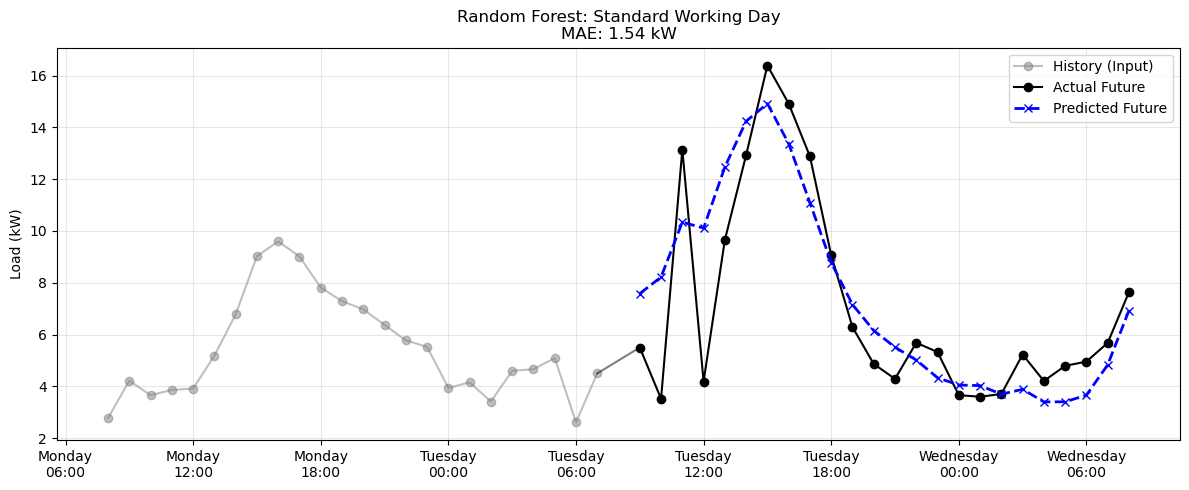

Checking Sunday -> Monday Transition...


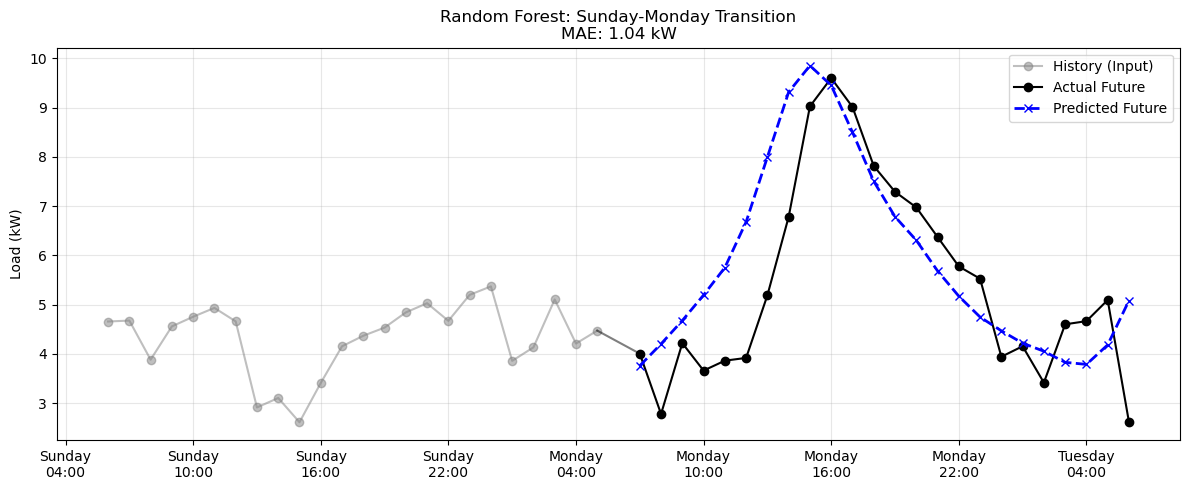

Checking Final Test Case (TestX0)...


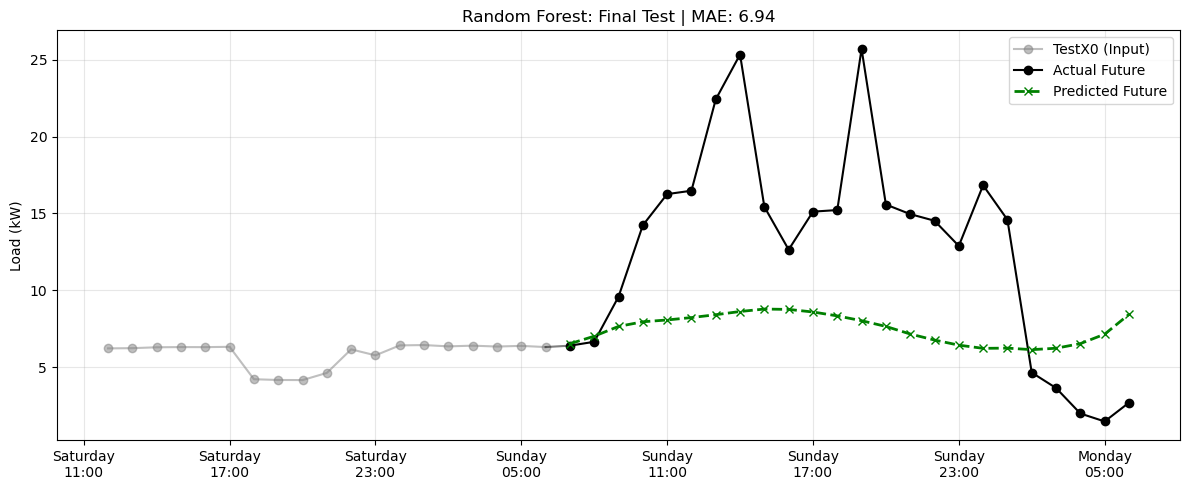


--- EVALUATION: Random Forest ---
>> Generating Training/Test Diagnostics...


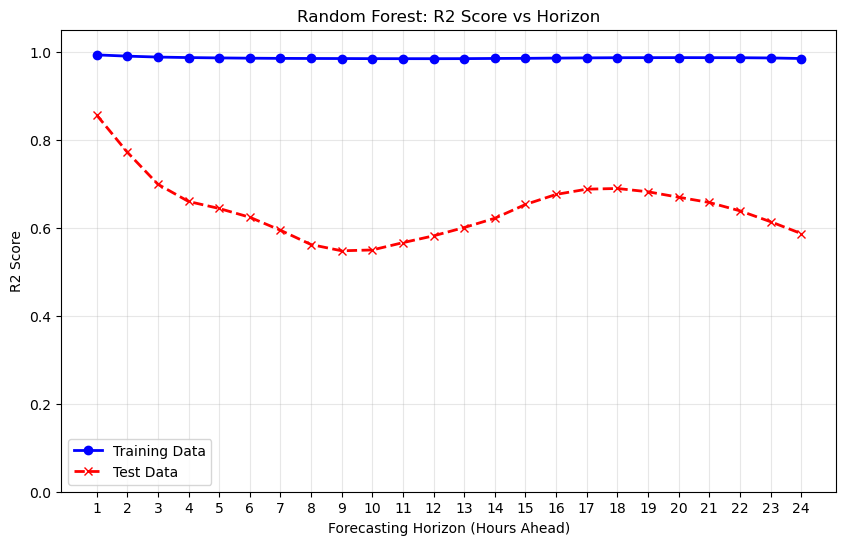

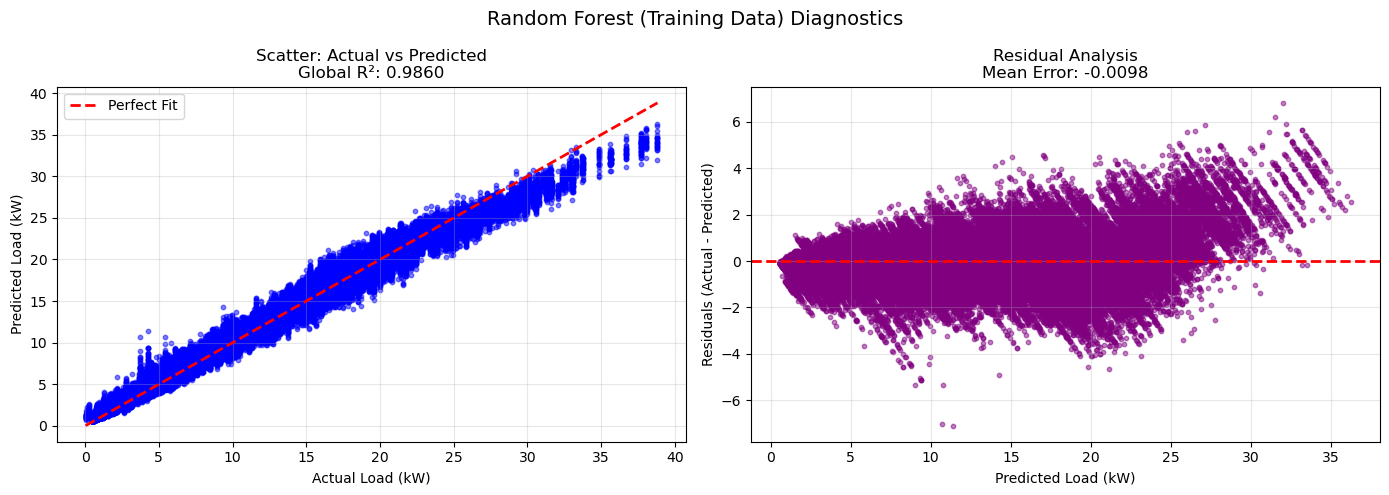

>> Evaluating Final Test Case (TestX0)...


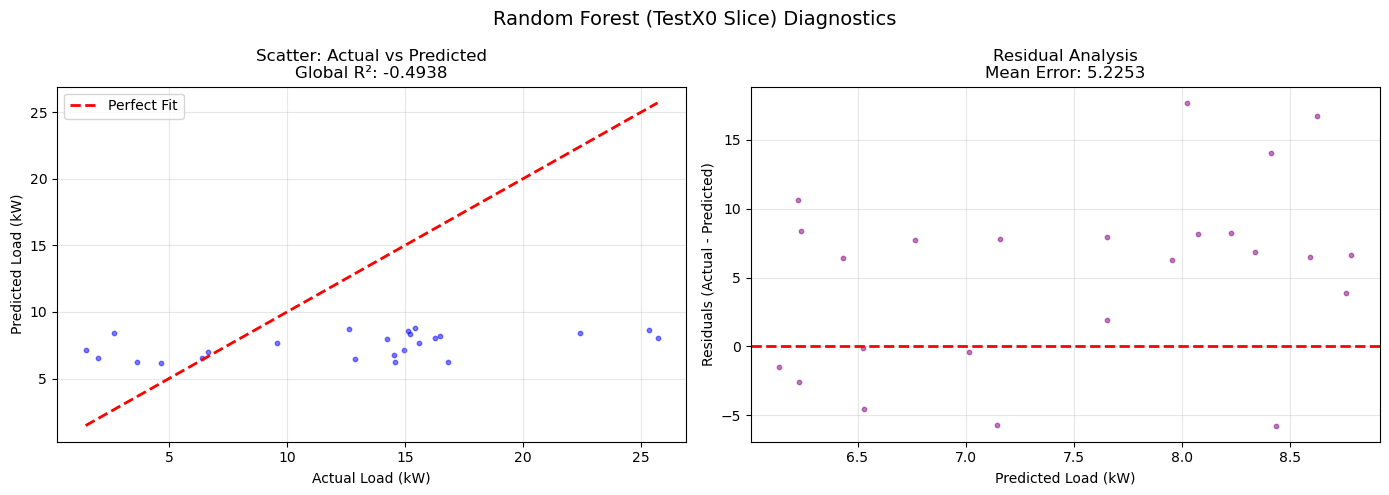

In [29]:
# First, ensure you have xgboost installed. If not, uncomment the next line:
# !pip install xgboost

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor # The industry standard for this task

# Reuse the 'run_complete_evaluation' function we defined in the previous step
# (Make sure that function is defined in your notebook!)

# =========================================================
# MODEL 2: RANDOM FOREST (The robust baseline)
# =========================================================
print("\n" + "="*50)
print("   TRAINING RANDOM FOREST")
print("="*50)

# n_estimators=150: More trees = more stable predictions
# max_depth=15: Prevents the model from memorizing noise (Overfitting)
rf_model = RandomForestRegressor(
    n_estimators=150, 
    max_depth=15,       
    random_state=42, 
    n_jobs=-1
)

run_complete_evaluation(rf_model, "Random Forest", X_train, y_train, X_test, testX0, y_train, y_test, testY0)

## 3.5. XGBoost Model

In [30]:
# # =========================================================
# # MODEL 3: XGBOOST (Gradient Boosting - Usually the best)
# # =========================================================
# print("\n" + "="*50)
# print("   TRAINING XGBOOST")
# print("="*50)

# # XGBoost is faster and often more accurate than Random Forest
# xgb_model = XGBRegressor(
#     n_estimators=200,
#     learning_rate=0.05, # Slower learning = better generalization
#     max_depth=6,        # Shallower trees prevent overfitting
#     random_state=42,
#     n_jobs=-1
# )

# run_complete_evaluation(xgb_model, "XGBoost", X_train, y_train, X_test, testX0, y_train, y_test, testY0)

## 3.6. FFNN Model

In [31]:
# import numpy as np
# import pandas as pd
# import tensorflow as tf
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import (
#     Dense, Dropout, LSTM, GRU, Bidirectional, 
#     Input, Conv1D, MaxPooling1D, Flatten, BatchNormalization
# )
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
# from sklearn.metrics import mean_squared_error, mean_absolute_error

# # =========================================================
# # KERAS REGRESSOR WRAPPER (Must run this cell first!)
# # =========================================================
# class KerasRegressorWrapper:
#     def __init__(self, model_type='ffnn', epochs=150, batch_size=32):
#         self.model_type = model_type
#         self.epochs = epochs
#         self.batch_size = batch_size
#         self.model = None
#         self.input_dim = None
        
#     def build_model(self):
#         model = Sequential()
#         out_dim = 24  # We always predict 24 hours ahead
        
#         # --- MODEL A: DEEP FFNN (Feed Forward) ---
#         if self.model_type == 'ffnn':
#             model.add(Input(shape=(self.input_dim,)))
#             model.add(Dense(512, activation='relu'))
#             model.add(BatchNormalization())
#             model.add(Dropout(0.3))
#             model.add(Dense(256, activation='relu'))
#             model.add(Dropout(0.3))
#             model.add(Dense(128, activation='relu'))
#             model.add(Dense(out_dim))
            
#         # --- MODEL B: DEEP LSTM ---
#         elif self.model_type == 'lstm':
#             # LSTM input shape: (Timesteps, Features). We treat it as 1 timestep.
#             model.add(Input(shape=(1, self.input_dim)))
#             model.add(LSTM(256, return_sequences=True))
#             model.add(BatchNormalization())
#             model.add(Dropout(0.3))
#             model.add(LSTM(128, return_sequences=False))
#             model.add(Dropout(0.3))
#             model.add(Dense(64, activation='relu'))
#             model.add(Dense(out_dim))

#         # --- MODEL C: GRU (Gated Recurrent Unit) ---
#         elif self.model_type == 'gru':
#             model.add(Input(shape=(1, self.input_dim)))
#             model.add(GRU(256, return_sequences=True))
#             model.add(Dropout(0.3))
#             model.add(GRU(128, return_sequences=False))
#             model.add(Dropout(0.3))
#             model.add(Dense(64, activation='relu'))
#             model.add(Dense(out_dim))
            
#         # --- MODEL D: BI-DIRECTIONAL LSTM ---
#         elif self.model_type == 'bilstm':
#             model.add(Input(shape=(1, self.input_dim)))
#             model.add(Bidirectional(LSTM(128, return_sequences=True)))
#             model.add(Dropout(0.3))
#             model.add(Bidirectional(LSTM(64, return_sequences=False)))
#             model.add(Dense(out_dim))

#         # Compile
#         model.compile(optimizer=Adam(learning_rate=0.0005), loss='mse')
#         self.model = model

#     def fit(self, X, y):
#         # 1. Set input dimensions dynamically based on X
#         self.input_dim = X.shape[1]
        
#         # 2. Build model if not built yet
#         if self.model is None:
#             self.build_model()
            
#         # 3. Reshape for RNNs (LSTM/GRU require 3D input: Samples, 1, Features)
#         if self.model_type in ['lstm', 'gru', 'bilstm']:
#             X = X.reshape((X.shape[0], 1, X.shape[1]))
            
#         # 4. Train
#         # Early Stopping prevents overfitting if epochs is too high
#         es = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
#         rlr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10)
        
#         self.model.fit(X, y, 
#                        validation_split=0.2, 
#                        epochs=self.epochs, 
#                        batch_size=self.batch_size, 
#                        callbacks=[es, rlr], 
#                        verbose=0) # Set verbose=1 to see training progress

#     def predict(self, X):
#         # Reshape for RNNs
#         if self.model_type in ['lstm', 'gru', 'bilstm']:
#             X = X.reshape((X.shape[0], 1, X.shape[1]))
        
#         # Predict (Output is Scaled 0-1)
#         pred_scaled = self.model.predict(X, verbose=0)
        
#         # IMPORTANT: Wrapper does NOT inverse transform here anymore.
#         # We handle inverse transform inside the 'run_universal_evaluation'
#         # or we assume the user passed scaled Y to fit, so output is scaled.
#         #
#         # HOWEVER: To make this "Universal" wrapper compatible with the function 
#         # 'run_universal_evaluation' which expects RAW OUTPUT from the model 
#         # (like Random Forest does), we must Inverse Transform HERE using the global scaler_y.
        
#         return scaler_y.inverse_transform(pred_scaled)

In [32]:
# from sklearn.preprocessing import MinMaxScaler
# import pandas as pd
# import numpy as np

# # 1. Initialize Scalers
# # We use separate scalers for Inputs (X) and Targets (y)
# scaler_X = MinMaxScaler()
# scaler_y = MinMaxScaler()

# # 2. Fit on Training Data ONLY (Prevent Data Leakage)
# print("Scaling Data...")
# X_train_scaled = scaler_X.fit_transform(X_train)
# y_train_scaled = scaler_y.fit_transform(y_train)

# # 3. Transform Validation Data (using the scaler fitted on train)
# X_test_scaled  = scaler_X.transform(X_test)
# y_test_scaled  = scaler_y.transform(y_test)

# # 4. Transform TestX0 (Final Test Input)
# TestX0_scaled = scaler_X.transform(testX0)

# # 5. Transform TestY0 (Final Test Target) - Needs Reshaping
# # Check if TestY0 is a Series or DataFrame and convert to numpy
# if isinstance(testY0, (pd.DataFrame, pd.Series)):
#     TestY0_vals = testY0.values
# else:
#     TestY0_vals = testY0

# # Reshape to (1, 24) because scaler_y expects 24 columns
# # If TestY0 is flat (24,), make it (1, 24)
# if TestY0_vals.ndim == 1:
#     TestY0_vals = TestY0_vals.reshape(1, -1)

# TestY0_scaled = scaler_y.transform(TestY0_vals)

# print("✅ Data Scaled Successfully.")
# print(f"X_train_scaled shape: {X_train_scaled.shape}")
# print(f"y_train_scaled shape: {y_train_scaled.shape}")

In [33]:
# # Initialize Wrapper
# ffnn = KerasRegressorWrapper('ffnn', epochs=100)

# # CALL FUNCTION WITH SCALED DATA
# run_complete_evaluation(
#     ffnn, "Deep FFNN",
#     X_train_scaled, y_train_scaled, # SCALED fit
#     X_test_scaled,                  # SCALED fit
#     TestX0_scaled,                  # SCALED fit
#     y_train, y_test, testY0         # RAW Real (For Plotting)
# )

In [34]:
# import matplotlib.pyplot as plt
# import numpy as np
# import pandas as pd
# from sklearn.ensemble import RandomForestRegressor, VotingRegressor
# from xgboost import XGBRegressor
# # You might need to install lightgbm: !pip install lightgbm
# from lightgbm import LGBMRegressor 
# from sklearn.multioutput import MultiOutputRegressor

# # =========================================================
# # 1. OPTIMIZED RANDOM FOREST
# # =========================================================
# print("\n" + "="*50)
# print("   MODEL 1: OPTIMIZED RANDOM FOREST")
# print("="*50)

# # Changes:
# # - min_samples_leaf=5: Forces "groups" of data, prevents memorizing single points.
# # - max_features='sqrt': Only looks at a subset of features per split (decorrelates trees).
# # - n_estimators=300: More trees to smooth variance.
# rf_opt = RandomForestRegressor(
#     n_estimators=300,
#     max_depth=15,
#     min_samples_split=10,
#     min_samples_leaf=5,      # Crucial for reducing overfitting
#     max_features='sqrt',     # Crucial for generalization
#     random_state=42,
#     n_jobs=-1
# )

# run_complete_evaluation(rf_opt, "Random Forest (Opt)", X_train, y_train, X_test, testX0, y_train, y_test, testY0)

# # =========================================================
# # 2. OPTIMIZED XGBOOST
# # =========================================================
# print("\n" + "="*50)
# print("   MODEL 2: OPTIMIZED XGBOOST")
# print("="*50)

# # Changes:
# # - learning_rate=0.02: Slower learning = better accuracy (requires more estimators).
# # - subsample=0.7: Only uses 70% of data for each tree (prevents overfitting).
# # - reg_alpha/reg_lambda: L1/L2 regularization to penalize complex models.
# xgb_opt = XGBRegressor(
#     n_estimators=500,        # Increased because LR is low
#     learning_rate=0.02,      # Low LR is key for Time Series
#     max_depth=6,
#     subsample=0.7,           # Randomly sample rows
#     colsample_bytree=0.7,    # Randomly sample columns
#     reg_alpha=0.1,           # L1 Regularization
#     reg_lambda=1.0,          # L2 Regularization
#     random_state=42,
#     n_jobs=-1
# )

# run_complete_evaluation(xgb_opt, "XGBoost (Opt)", X_train, y_train, X_test, testX0, y_train, y_test, testY0)

# # =========================================================
# # 3. LIGHTGBM (New High-Performance Model)
# # =========================================================
# print("\n" + "="*50)
# print("   MODEL 3: LIGHTGBM")
# print("="*50)

# # LightGBM is often faster and more accurate than XGBoost.
# # Since LGBM doesn't support MultiOutput natively for regression chains, 
# # we wrap it in MultiOutputRegressor.
# lgbm = LGBMRegressor(
#     n_estimators=500,
#     learning_rate=0.02,
#     num_leaves=31,           # Controls complexity
#     max_depth=-1,            # Let num_leaves handle depth
#     subsample=0.7,
#     colsample_bytree=0.7,
#     random_state=42,
#     n_jobs=-1,
#     verbose=-1               # Silence warnings
# )

# lgbm_opt = MultiOutputRegressor(lgbm)
# run_complete_evaluation(lgbm_opt, "LightGBM", X_train, y_train, X_test, testX0, y_train, y_test, testY0)

# # =========================================================
# # 4. VOTING ENSEMBLE (The "Best of All" Approach)
# # =========================================================
# print("\n" + "="*50)
# print("   MODEL 4: VOTING ENSEMBLE (RF + XGB + LGBM)")
# print("="*50)

# # # We average the predictions of the 3 optimized models.
# # # This usually gives the lowest RMSE because errors cancel each other out.
# # voting_model = VotingRegressor([
# #     ('rf', rf_opt),
# #     ('xgb', xgb_opt),
# #     ('lgbm', lgbm_opt)
# # ])

# # run_complete_evaluation(voting_model, "Voting Ensemble", X_train, y_train, X_test, y_test, testX0, testY0)

In [35]:
# from sklearn.multioutput import MultiOutputRegressor
# from sklearn.ensemble import VotingRegressor
# from xgboost import XGBRegressor
# from sklearn.ensemble import RandomForestRegressor
# from lightgbm import LGBMRegressor

# print("\n" + "="*50)
# print("   TRAINING FINAL ENSEMBLE (Fixed for 24h Output)")
# print("="*50)

# # 1. Define Base Models
# # XGBoost: Low learning rate for accuracy
# xgb_final = XGBRegressor(
#     n_estimators=300, 
#     learning_rate=0.03, 
#     max_depth=6, 
#     random_state=42, n_jobs=-1
# )

# # LightGBM: Good for time series
# lgbm_final = LGBMRegressor(
#     n_estimators=300,
#     learning_rate=0.03,
#     num_leaves=30,
#     random_state=42, n_jobs=-1, verbose=-1
# )

# # Random Forest: Adds stability
# rf_final = RandomForestRegressor(
#     n_estimators=150,
#     max_depth=10,
#     min_samples_leaf=4,
#     random_state=42, n_jobs=-1
# )

# # 2. Create Voting Ensemble
# voting_reg = VotingRegressor([
#     ('xgb', xgb_final),
#     ('lgbm', lgbm_final),
#     ('rf', rf_final)
# ])

# # 3. *** CRITICAL FIX ***
# # Wrap the VotingRegressor in MultiOutputRegressor.
# # This creates 24 separate voting models (one for each future hour).
# multi_output_voting = MultiOutputRegressor(voting_reg)

# # 4. Run Evaluation
# run_complete_evaluation(multi_output_voting, "Voting Ensemble (Final)", X_train, y_train, X_test, testX0, y_train, y_test, testY0)

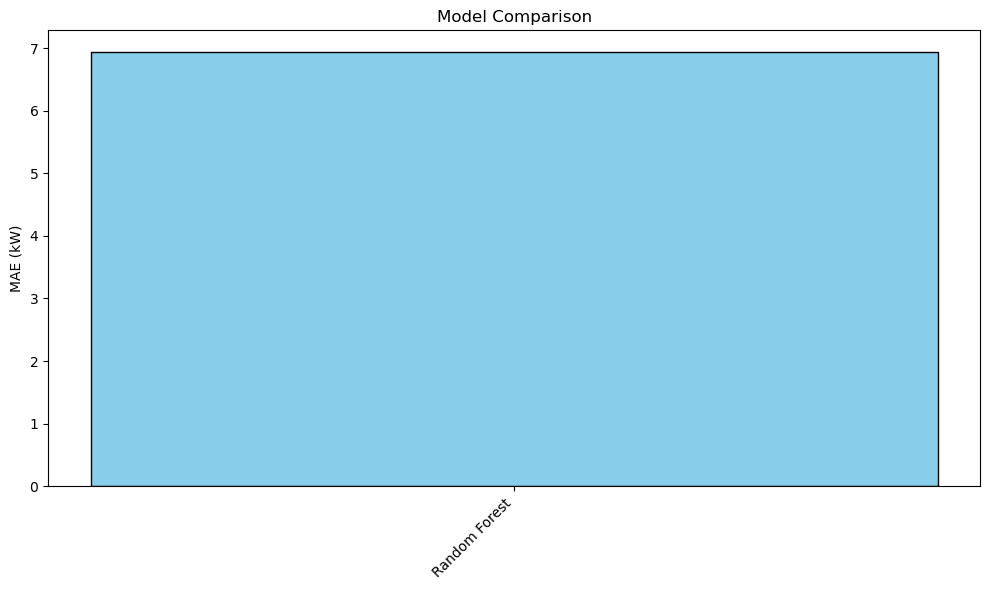

In [36]:
x = []
y = []

for a in MAE_test_models:
    x.append(a)
    y.append(MAE_test_models[a])


plt.figure(figsize=(10, 6)) # Make the plot wider
plt.bar(x, y, color='skyblue', edgecolor='black')

# Rotate labels 45 degrees and align them to the right
plt.xticks(rotation=45, ha='right')

plt.ylabel("MAE (kW)")
plt.title("Model Comparison")
plt.tight_layout() # Ensures labels don't get cut off
plt.show()

# 5. Final format and export to csv

<b style="color:red;">IMPORTANT</b>: you will hand over the final results of the test data to us as csv-file. 

<b style="color:black;">We will not make the forecasts for you even if we request the model(s) and notebooks</b>

The final format should be created like shown below as 2-d numpy array (first number of .shape shows the number of test datasets, second number must be 24 according to the task) and saved as csv.

In [39]:
# Calling all files and saving data
for i in range(44):
    t_slice = pd.read_csv(f"Data/my_slices/test_X_slice_{i}.csv")
    t_slice['Time'] = pd.to_datetime(t_slice['Time'])
    t_slice = t_slice.drop_duplicates(subset='Time').set_index('Time').sort_index()
    features_t_slice = feature_engineering(t_slice)
    pred_t_slice = rf_model.predict(features_t_slice.iloc[[-1]]).flatten()
    if i == 0:
        final_submission_array = pred_t_slice
    else:
        # Append forecast to final_submission_array
        final_submission_array = np.vstack([final_submission_array, pred_t_slice])
    
print(f'Forecast numpy array: \n {final_submission_array}\n')

print(f'Shape forecast numpy array:{final_submission_array.shape}')

Forecast numpy array: 
 [[15.61474669 17.36003669 17.98078825 ...  8.68646664 11.96557595
  14.88503268]
 [ 6.19160703  7.26517599  8.81099511 ...  5.5125862   5.47212743
   5.53365367]
 [ 5.93087903  5.8172559   5.57843023 ...  8.81148156  7.99865685
   7.26033787]
 ...
 [ 5.76878306  5.65088675  5.60099305 ...  4.84088926  4.83755737
   4.85011734]
 [11.28154819  9.73896259  9.04488165 ... 19.18779841 17.32775717
  14.56544458]
 [15.14059375 16.7044323  17.31224123 ...  9.22642929 11.9870333
  14.666004  ]]

Shape forecast numpy array:(44, 24)


In [42]:
# Save it like this as csv
np.savetxt("Data/my_results/DataChallenge2526_ML_Results_Group_21.csv", final_submission_array, delimiter=",") # xy would be 01, 02, ... 10, ... according to the group number